# Customer Personality Segmentation
## Project Summary

**Type:** Unsupervised Machine Learning — K-Means Clustering
**Dataset:** 2,240 customers | 29 features | Kaggle Customer Personality Analysis
**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, SciPy

---

### What This Project Does
Uses K-Means clustering to segment retail customers into distinct
personality groups based on demographics, spending behavior, and
purchasing patterns. Follows a structured 13-step data science workflow
from business problem definition through business recommendations.

### Key Results
- **4 customer segments identified** from 2,230 customers and 24 features
- **Silhouette Score: 0.1901** — acceptable for real-world,
  high-dimensional customer data
- **6 hypotheses tested** using correlation tests, t-tests, and ANOVA

### Customer Segments Found
| Cluster | Name | Size | Key Characteristic |
|---|---|---|---|
| 0 | Deal Seekers | 581 | Moderate income, deal-driven, active web buyers |
| 1 | Budget Browsers | 1,012 | Low income, high web visits, low conversion |
| 2 | Premium Loyalists | 560 | High income, high spend, campaign responsive |
| 3 | Campaign Responsive Seniors | 77 | Oldest segment, store preference, wine buyers |

### Project Structure
```
13-Step Flow:
Steps 1-4   → Foundation (Business Problem, Data Understanding,
               Preparation, Feature Engineering)
Step 5      → Exploratory Data Analysis (7 business questions)
Steps 6-7   → Hypothesis Formation and Statistical Testing
Steps 8-10  → Preprocessing, Modeling, Evaluation
Steps 11-12 → Initial Insights and Model Tuning
Step 13     → Business Recommendations and Documentation
```
---

### Step 1: Business Problem

A retail company wants to understand who their customers really are — not just
as a single group, but as distinct types of people with different behaviors,
needs, and spending patterns.

Right now, the company treats all customers the same way when it comes to
marketing. The goal of this project is to use data to find natural groupings
in their customer base, so the company can make smarter decisions about who
to target, how, and with what.

#### Central Question

Can we identify distinct customer segments based on demographics, spending
behavior, and purchasing patterns — and what does each segment tell us about
how to serve them better?

#### What a Good Answer Looks Like

- Clear, separable customer groups that behave differently from each other
- A profile for each group describing who they are and how they spend
- Actionable recommendations the business can actually use

#### Approach

This project follows a structured 13-step data science workflow:
Foundation → Exploration → Hypothesis Testing → Modeling → Insights →
Communication

#### Dataset — Data Dictionary

Source: Kaggle — Customer Personality Analysis
Link: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

**People**
| Column | Description |
|---|---|
| ID | Customer's unique identifier |
| Year_Birth | Customer's birth year |
| Education | Customer's education level |
| Marital_Status | Customer's marital status |
| Income | Customer's yearly household income |
| Kidhome | Number of children in customer's household |
| Teenhome | Number of teenagers in customer's household |
| Dt_Customer | Date of customer's enrollment with the company |
| Recency | Number of days since customer's last purchase |
| Complain | 1 if customer complained in last 2 years, 0 otherwise |

**Products — Amount spent in last 2 years**
| Column | Description |
|---|---|
| MntWines | Amount spent on wine |
| MntFruits | Amount spent on fruits |
| MntMeatProducts | Amount spent on meat |
| MntFishProducts | Amount spent on fish |
| MntSweetProducts | Amount spent on sweets |
| MntGoldProds | Amount spent on gold |

**Promotion**
| Column | Description |
|---|---|
| NumDealsPurchases | Number of purchases made with a discount |
| AcceptedCmp1-5 | 1 if customer accepted offer in that campaign, 0 otherwise |
| Response | 1 if customer accepted offer in the last campaign, 0 otherwise |

**Place — Purchase channels**
| Column | Description |
|---|---|
| NumWebPurchases | Purchases made through the website |
| NumCatalogPurchases | Purchases made using a catalogue |
| NumStorePurchases | Purchases made directly in stores |
| NumWebVisitsMonth | Website visits in the last month |

### Step 2: Data Understanding
---
#### Observations

**Shape:**
- 2,240 customers and 29 columns.

**Data Types:**
- 25 columns are numeric integers (int64)
- 1 column is float (Income)
- 3 columns are strings (Education, Marital_Status, Dt_Customer)

**Missing Values:**
- Income has 24 missing values (2,216 out of 2,240 rows have data)
- All other columns are complete
- Will handle Income missing values in the data preparation step

**Columns to flag for later decisions:**
- Z_CostContact and Z_Revenue have the same value (3 and 11) across
  every row — no variation, no useful information for clustering
- Dt_Customer is stored as a string but should be a date
- Education and Marital_Status are categorical — need encoding or
  dropping before clustering can be applied

In [1]:
# Importing the libraries needed for this project.
# Each library serves a specific purpose explained below.

import pandas as pd                                 # for loading and working with tabular data
import numpy as np                                  # for numerical operations
import matplotlib.pyplot as plt                     # for creating plots
import seaborn as sns                               # for nicer looking statistical plots
import warnings                                     # to suppress unnecessary warnings

from sklearn.preprocessing import StandardScaler    # for scaling data before clustering
from sklearn.cluster import KMeans                  # the clustering algorithm
from sklearn.decomposition import PCA               # for reducing dimensions to visualize clusters
from sklearn.metrics import silhouette_score        # for evaluating cluster quality
from scipy import stats                             # for statistical hypothesis testing

import time                                         # to measure how long the model takes to train

warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset from the local data folder.
# The path goes up two levels from this notebook's location,
# then into the datasets folder where the CSV is stored.

data = pd.read_csv("../../datasets/Customer_Personality_Segmentation.csv", sep='\t')

In [3]:
# Looking at the first 5 rows to get a feel for the data.
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# Checking the shape of the dataset - how many rows and columns we have.
print("Rows and Columns:", data.shape)

Rows and Columns: (2240, 29)


In [5]:
# Getting a summary of each column - data types and whether there are missing values.
# This is the first real look at data quality.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
# Statistical summary of all numeric columns.
# This shows the range, average, and spread of each variable.
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### Step 3: Data Preparation
---

#### Observations and Actions

Changes made to the data and the reason for each:

1. **Dt_Customer** — converted from string to datetime so Python can
   work with it as a date.

2. **Duplicates** — checked and confirmed zero duplicate rows.
   No action needed.

3. **Income missing values** — 24 rows had no income value.
   Used median imputation (51,381.5) instead of mean because Income
   is right-skewed with extreme outliers. Median is more stable in
   this case.

4. **Year_Birth outliers** — 3 customers had birth years before 1926,
   making them over 100 years old. Treated as data entry errors and
   removed. 24 customers aged 80-100 were reviewed and kept — their
   income, education, and marital status looked like real customers.

5**Marital_Status invalid values** — 7 rows with values Absurd, YOLO,
   and Alone were removed as data entry errors. These are not valid
   marital status categories.

**Rows remaining after preparation: 2,230**

In [7]:
# Saving the original raw data as a separate copy before making any changes.
# data_raw will never be modified - it is the ground truth we can always refer back to.
# All changes from this point forward are made directly on data.
data_raw = data.copy()

In [8]:
# Dt_Customer is stored as a string but it represents a date.
# Converting it to datetime so Python understands it as a date.
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True)

# Confirming the conversion worked.
print(data['Dt_Customer'].dtype)
print(data['Dt_Customer'].head())

datetime64[us]
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]


In [9]:
# Checking for duplicate rows.
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [10]:
# Handling the 24 missing Income values.
# From describe(), Income is right-skewed with extreme outliers.
# The median is a better choice than mean here because mean gets pulled up by very high values like 666,666 - the median is more stable.

median_income = data['Income'].median()
print("Median Income used for imputation:", median_income)

data['Income'] = data['Income'].fillna(median_income)

# Confirming no missing values remain in Income.
print("Missing values in Income after imputation:",
      data['Income'].isnull().sum())

Median Income used for imputation: 51381.5
Missing values in Income after imputation: 0


In [11]:
# Checking Year_Birth for unusual values.
# We want to know the range of birth years to spot any values that look like data entry errors rather than real customers.
print("Oldest birth year:", data['Year_Birth'].min())
print("Youngest birth year:", data['Year_Birth'].max())

Oldest birth year: 1893
Youngest birth year: 1996


In [12]:
# Splitting the unusual birth years into two groups.
# Over 100 years old - almost certainly data entry errors.
over_100 = data[data['Year_Birth'] < 1926]
print("Customers over 100 years old:")
print(over_100[['ID', 'Year_Birth', 'Income', 'Marital_Status', 'Education']])
print()

# Between 80-100 years old - unusual but needs closer look before deciding.
between_80_100 = data[(data['Year_Birth'] >= 1926) & (data['Year_Birth'] < 1946)]
print("Customers between 80-100 years old:")
print(between_80_100[['ID', 'Year_Birth', 'Income', 'Marital_Status', 'Education']])

Customers over 100 years old:
        ID  Year_Birth   Income Marital_Status Education
192   7829        1900  36640.0       Divorced  2n Cycle
239  11004        1893  60182.0         Single  2n Cycle
339   1150        1899  83532.0       Together       PhD

Customers between 80-100 years old:
         ID  Year_Birth    Income Marital_Status   Education
39     2968        1943   48948.0       Divorced         PhD
103    9370        1945   65846.0        Married         PhD
161    9260        1945   70356.0        Married         PhD
358    6142        1943   65073.0        Married      Master
415    7106        1943   75865.0        Married         PhD
424    6932        1941   93027.0        Married         PhD
494    6605        1944   55614.0       Divorced         PhD
499     466        1944   65275.0        Married  Graduation
519    3711        1944   80184.0        Married      Master
611    4587        1944   45006.0          Widow      Master
790    6543        1945   62847.0 

In [13]:
# Dropping the 3 rows where Year_Birth is before 1926.
# These customers would be over 100 years old which is not realistic. The 80-100 age group looks like real customers so we are keeping them.
data = data[data['Year_Birth'] >= 1926]

# Confirming the rows were removed.
print("Rows remaining after dropping:", len(data))

Rows remaining after dropping: 2237


In [14]:
# Dropping columns that have no analytical value.
# Z_CostContact and Z_Revenue have the same value for every single row. # A column with no variation cannot tell us anything about customer differences.
data = data.drop(columns=['Z_CostContact', 'Z_Revenue'])

print("Columns remaining after dropping:", data.shape[1])

Columns remaining after dropping: 27


In [15]:
# Checking how many customers have invalid marital status values.
print(data['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [16]:
# Removing rows with invalid Marital Status values.
# Absurd, YOLO and Alone are not valid marital status categories.
# These are likely data entry errors similar to the invalid birth years.
invalid_marital = ['Absurd', 'YOLO', 'Alone']
data = data[~data['Marital_Status'].isin(invalid_marital)]

print("Rows remaining after dropping invalid marital status:", len(data))

Rows remaining after dropping invalid marital status: 2230


### Step 4: Feature Engineering
---

#### Observations and Actions

Created 5 new columns from existing data:
| New Column | Built From | Why |
|---|---|---|
| TotalSpend | Sum of 6 product spend columns | Single view of overall spending behavior |
| TotalPurchases | Sum of web + catalog + store purchases | Single view of purchasing activity |
| TotalCampaignAcceptance | Sum of 5 campaign flags | Single view of campaign responsiveness |
| Age | Current year minus Year_Birth | More intuitive than birth year for analysis |
| Customer_Tenure | Days from Dt_Customer to today | Captures how long they have been a customer |
| NumCategories | Count of product categories with spend > 0 | Captures breadth of purchasing behavior |


These derived columns carry more analytical signal than the raw columns
they came from. They will be used throughout EDA and clustering.

In [17]:
# Total amount spent across all product categories.
# Adding up wines, fruits, meat, fish, sweets, and gold products.
data['TotalSpend'] = data[['MntWines', 'MntFruits', 'MntMeatProducts',
                            'MntFishProducts', 'MntSweetProducts',
                            'MntGoldProds']].sum(axis=1)

# Total number of purchases across all channels.
# Adding up web, catalog, and store purchases.
data['TotalPurchases'] = data[['NumWebPurchases', 'NumCatalogPurchases',
                                'NumStorePurchases']].sum(axis=1)

# Total number of marketing campaigns the customer accepted.
data['TotalCampaignAcceptance'] = data[['AcceptedCmp1', 'AcceptedCmp2',
                                         'AcceptedCmp3', 'AcceptedCmp4',
                                         'AcceptedCmp5']].sum(axis=1)

# Customer age derived from birth year.
data['Age'] = pd.Timestamp.today().year - data['Year_Birth']

# How long the customer has been with the company in days.
# Assuming Dt_Customer is the date they enrolled - subtracting from today gives tenure.
data['Customer_Tenure'] = (pd.Timestamp.today() - data['Dt_Customer']).dt.days

# Number of product categories the customer purchased from.
# A customer buying across many categories behaves differently
# from one who only buys from one or two.
data['NumCategories'] = (
    (data['MntWines'] > 0).astype(int) +
    (data['MntFruits'] > 0).astype(int) +
    (data['MntMeatProducts'] > 0).astype(int) +
    (data['MntFishProducts'] > 0).astype(int) +
    (data['MntSweetProducts'] > 0).astype(int) +
    (data['MntGoldProds'] > 0).astype(int)
)

# Previewing the new columns alongside key identifiers.
data[['ID', 'TotalSpend', 'TotalPurchases',
      'TotalCampaignAcceptance', 'Age',
      'Customer_Tenure', 'NumCategories'
      ]].head()

,ID,TotalSpend,TotalPurchases,TotalCampaignAcceptance,Age,Customer_Tenure,NumCategories
0,5524,1617,22,0,69,4958,6
1,2174,27,4,0,72,4408,6
2,4141,776,20,0,61,4607,6
3,6182,53,6,0,42,4434,6
4,5324,422,14,0,45,4456,6


### Step 5: Exploratory Data Analysis (EDA)
---

Questions going into EDA:
1. Does age influence which product categories customers buy?
2. Does income influence promotion usage?
3. Does income influence total spend and category breadth?
4. Does age influence which purchase channel customers use?
5. Does recency (gap since last purchase) relate to overall spend?
6. Does education level influence which product categories customers
   spend on? (e.g. do PhD customers spend more on premium products?)
7. Does web visit frequency correlate with web purchases?

#### Observations and Actions:

#### 5.1 Univariate Analysis
---
##### Histogram Observations

**Demographics:**
- Age follows a bell curve with most customers in the middle-aged range
- Income is right-skewed — most customers have moderate income with
  a long tail of high earners
- Year_Birth mirrors Age as expected — both show the same bell curve
- About 50% of customers have no children. Very few have more than 1 child

**Spending:**
- All product spending columns share the same shape — most customers
  spend low with a right-skewed tail of high spenders
- Wine has the widest spending range — customers spread across low to
  high spend on wine
- Gold has most customers clustered at low spend with a sharp drop-off

**Purchase Channels:**
- Web purchases are the most prominent channel with the widest range
- Catalog purchases follow web
- Store purchases are the least with a staggered distribution

**Campaigns:**
- Very low campaign acceptance across all 5 campaigns
- The vast majority of customers did not accept any campaign

**Derived Features:**
- TotalSpend is right-skewed — most customers are low spenders
- TotalPurchases shows a bimodal distribution — two distinct groups
  of customers with different purchasing activity levels. This is a
  signal that clustering may find meaningful separation here
- Customer_Tenure shows multiple peaks — customers enrolled in waves
  suggesting the company ran acquisition campaigns at specific points
- NumCategories — about 1,400 out of 2,237 customers buy across all
  6 product categories. Very little variation. May not be useful for
  clustering — flagged for review in preprocessing step

##### Box Plot Observations
- **Income** — significant outliers on the high end. The box sits
  below 100,000 but the Y-axis stretches to 600,000 showing extreme
  high income values exist in the dataset
- **Age** — clean distribution with no outliers. All customers fall
  within a normal range
- **TotalSpend** — box is compressed at the low end with a long upper
  tail. High spending customers are outliers relative to the majority
- **Spending columns** — all product categories follow the same pattern
  as TotalSpend. Most customers spend low with outliers on the high end
- **Wine** — has the widest box of all product categories indicating
  more variation in wine spending compared to other products
- **Purchase channels** — all three channels show outliers on the
  high end. Some customers make significantly more purchases than
  the majority across all channels

**Key takeaway:** Income and all spending variables have high-end
outliers. Scaling will be essential before clustering to prevent
these extreme values from dominating distance calculations.

In [18]:
# Setting the plot style for all charts in this notebook.
sns.set(style='whitegrid')

# Selecting all numeric columns from the dataset.
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ID is just a unique identifier - it has no analytical value. # Removing it so it does not show up in our plots.
numeric_cols.remove('ID')

print("Columns included in univariate analysis:")
print(numeric_cols)
print()
print("Total columns:", len(numeric_cols))

Columns included in univariate analysis:
['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'TotalSpend', 'TotalPurchases', 'TotalCampaignAcceptance', 'Age', 'Customer_Tenure', 'NumCategories']

Total columns: 29


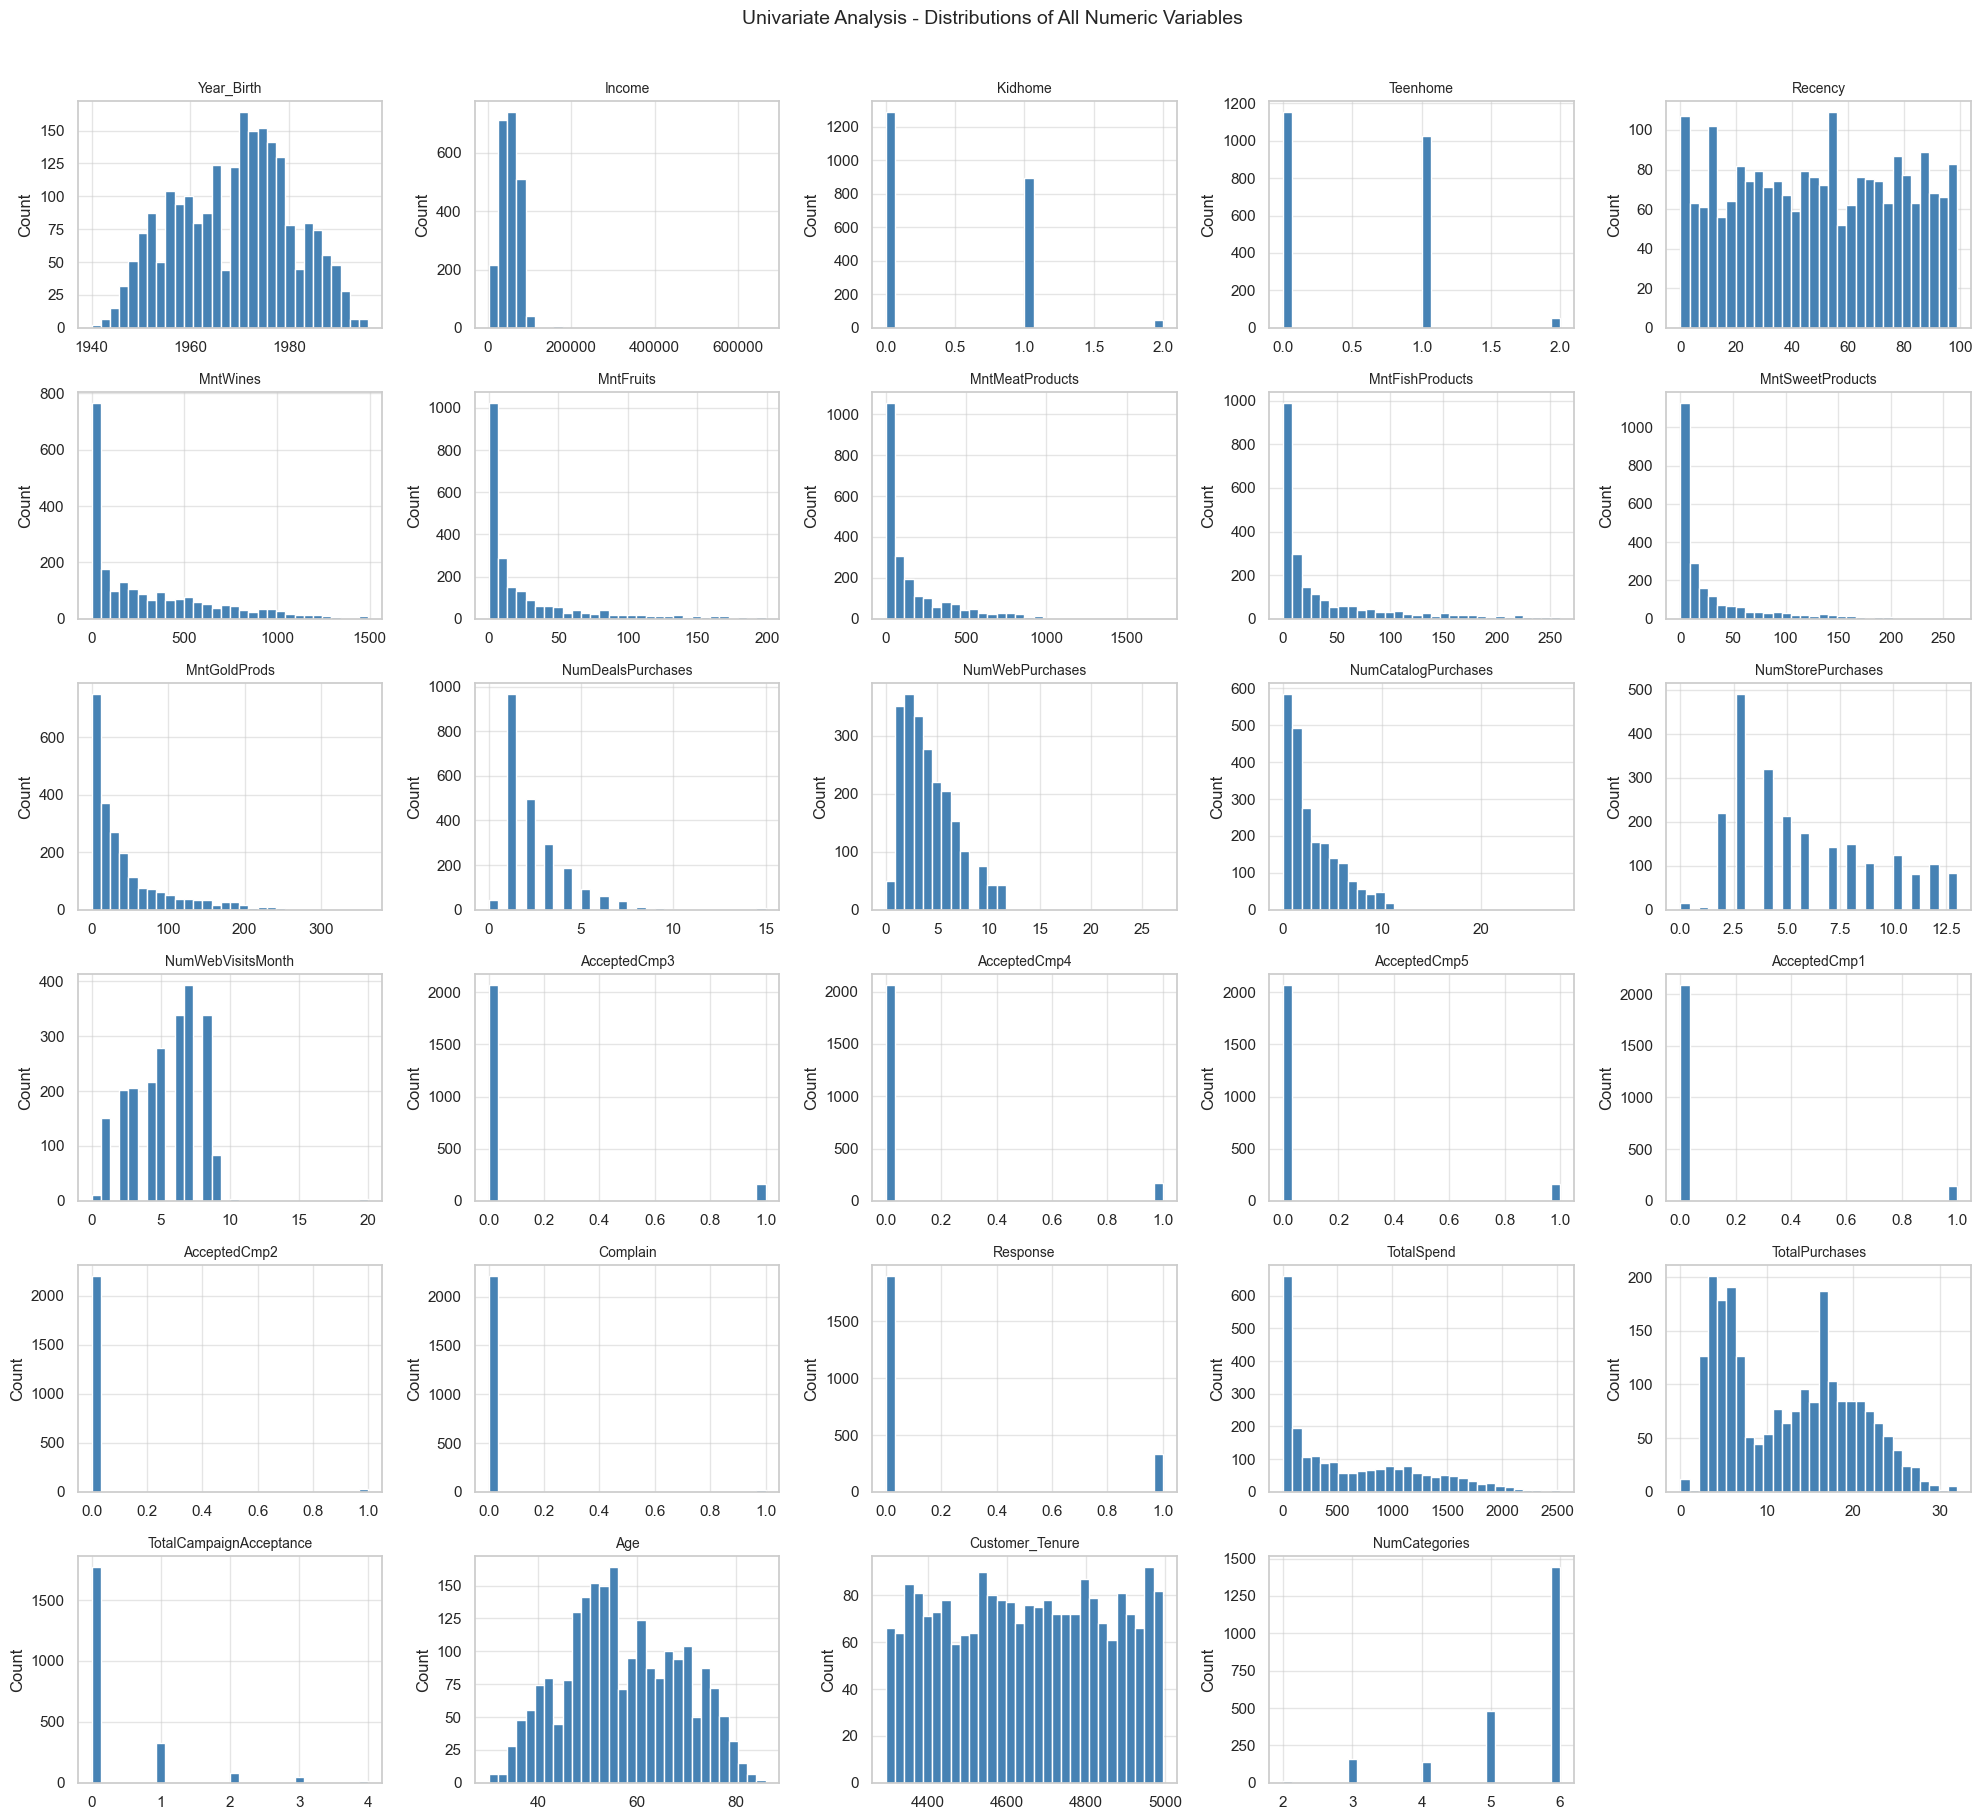

In [19]:
# Plotting a histogram for every numeric column.
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 18))

# Flatten the 2D grid of axes into a simple list so we can loop through them.
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hiding the last empty subplot since we have 29 columns but 30 grid slots.
axes[29].set_visible(False)

plt.suptitle('Univariate Analysis - Distributions of All Numeric Variables',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

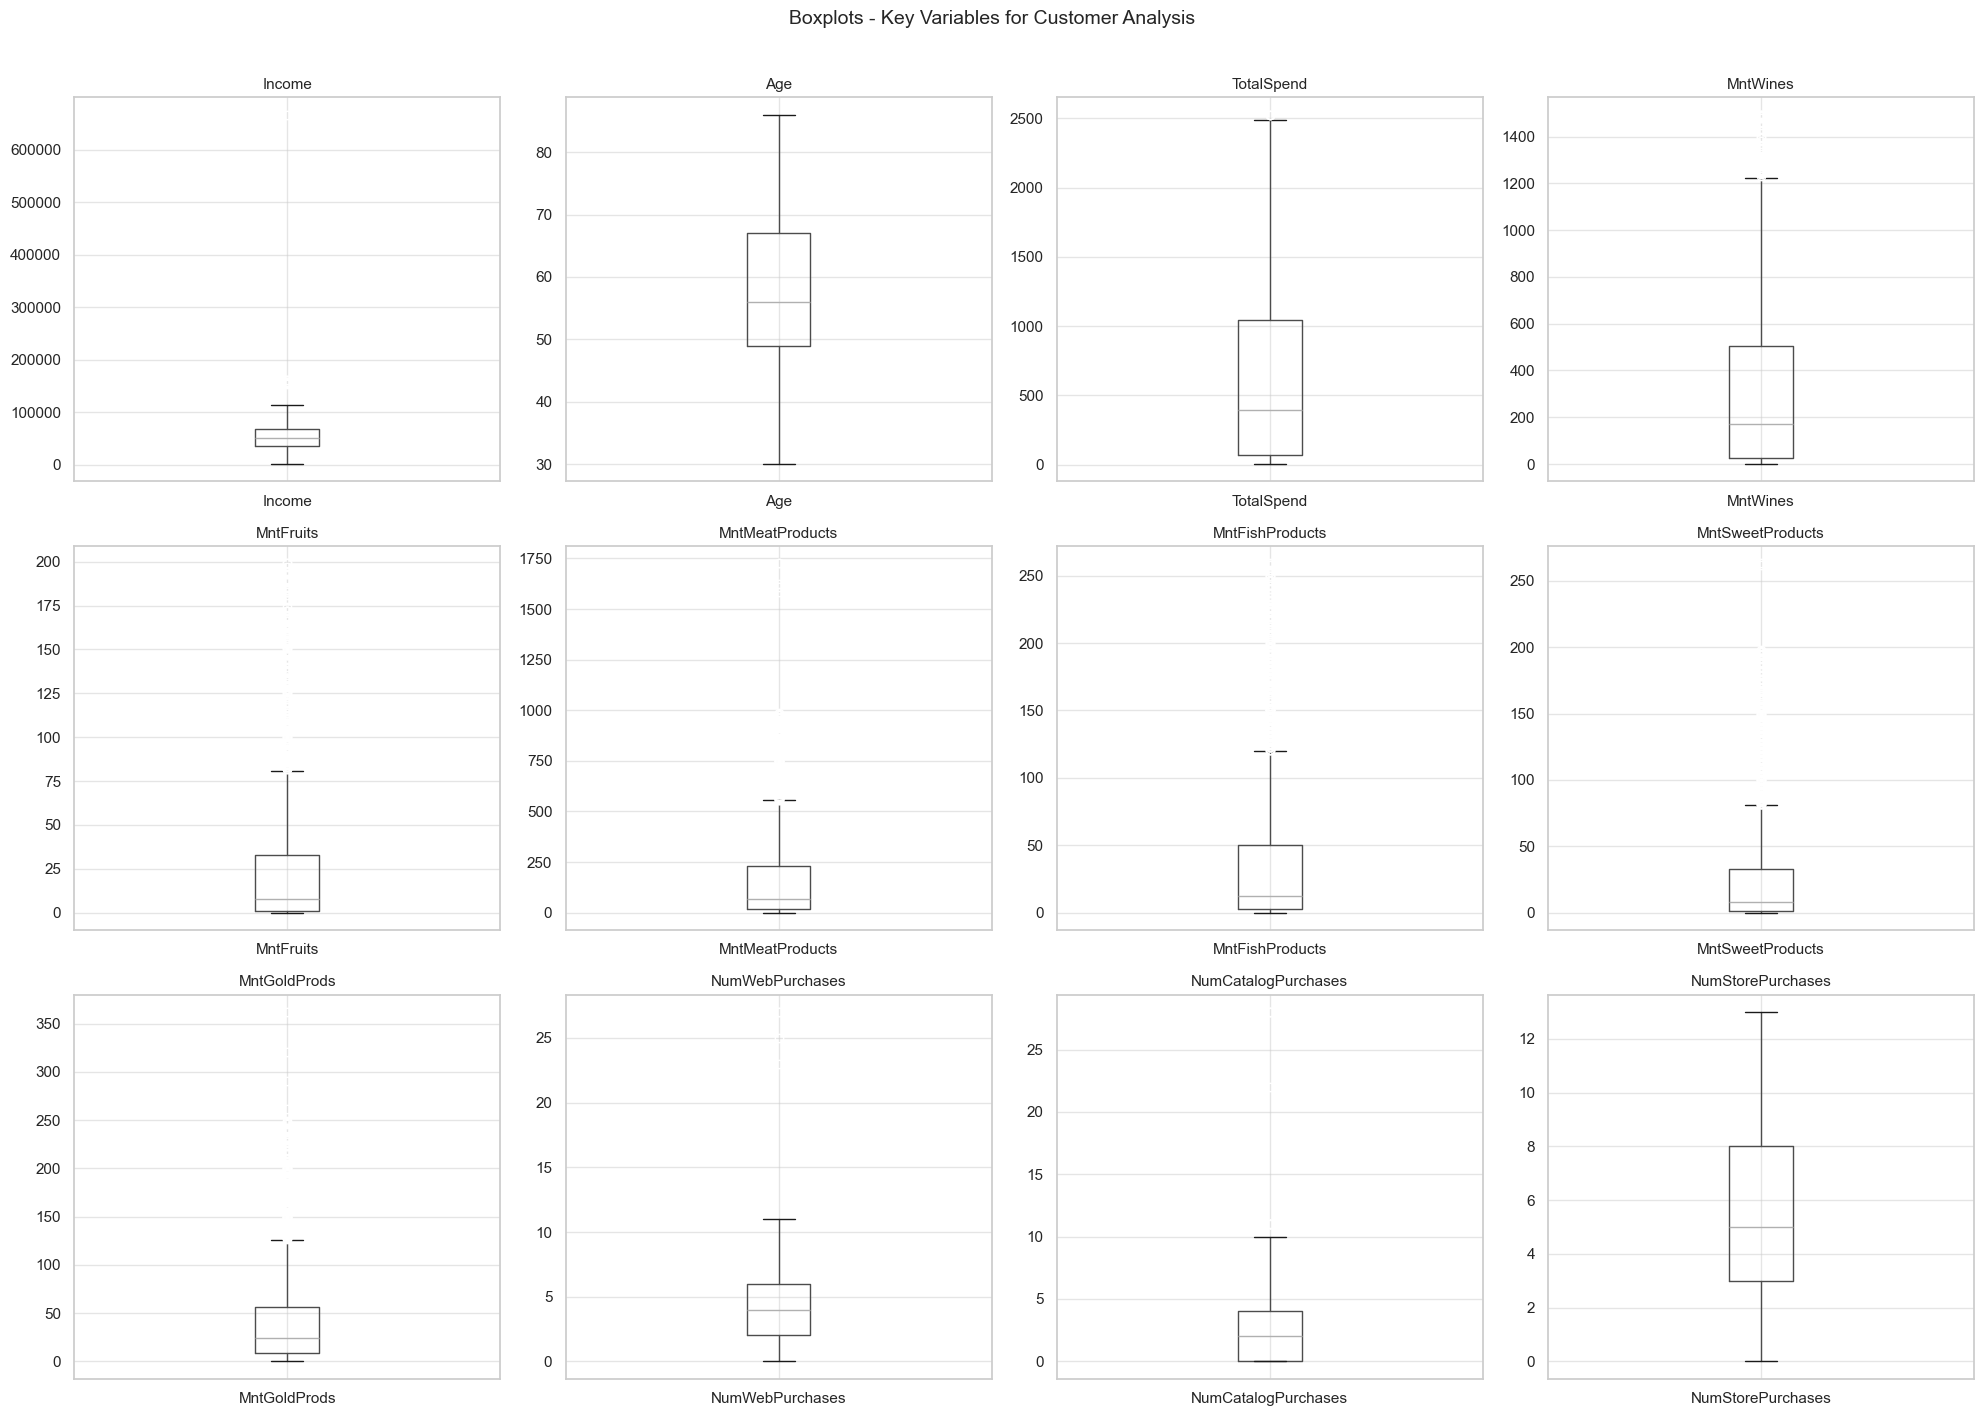

In [20]:
# Plotting boxplots for the most analytically important variables.
# These columns represent income, spending, purchase channels, and age.
# Boxplots help us spot outliers - values that sit far outside the normal range.

key_cols = ['Income', 'Age', 'TotalSpend',
            'MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
            'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 14))

axes = axes.flatten()

for i, col in enumerate(key_cols):
    data.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots - Key Variables for Customer Analysis',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Bivariate Analysis

#### Correlation Heatmap Observation

**Income and Spending:**
- Income has a moderate positive correlation with TotalSpend (0.66) —
  higher income customers tend to spend more but it is not a perfect
  relationship
- Income correlates strongly with catalog purchases (0.59) and
  store purchases (0.53)

**Strongest drivers of TotalSpend:**
- TotalPurchases (0.82), MntWines (0.89), MntMeatProducts (0.84),
  and NumCatalogPurchases (0.78) are the strongest correlates of
  total spend

**Web Visits vs Purchasing:**
- NumWebVisitsMonth has a negative correlation with Income (-0.55),
  TotalSpend (-0.50), and most purchase channels
- Customers who visit the website most are low income and buy least —
  they are browsing not buying

**Kids at Home:**
- Kidhome correlates positively with NumDealsPurchases (0.22) and
  NumWebVisitsMonth (0.45)
- Customers with kids browse more and use more deals but do not
  convert to purchases — budget-conscious, deal-hunting behavior

**Age:**
- Age has very weak correlations across all variables
- Slight positive correlation with wine (0.16) — older customers
  lean slightly more toward wine spending

**Recency:**
- Almost no correlation with any variable — how long since last
  purchase does not predict what or how much a customer buys

**Campaign Acceptance:**
- Low but positive correlation with Income (0.31) and TotalSpend
  (0.46) — higher value customers are slightly more responsive to
  campaigns

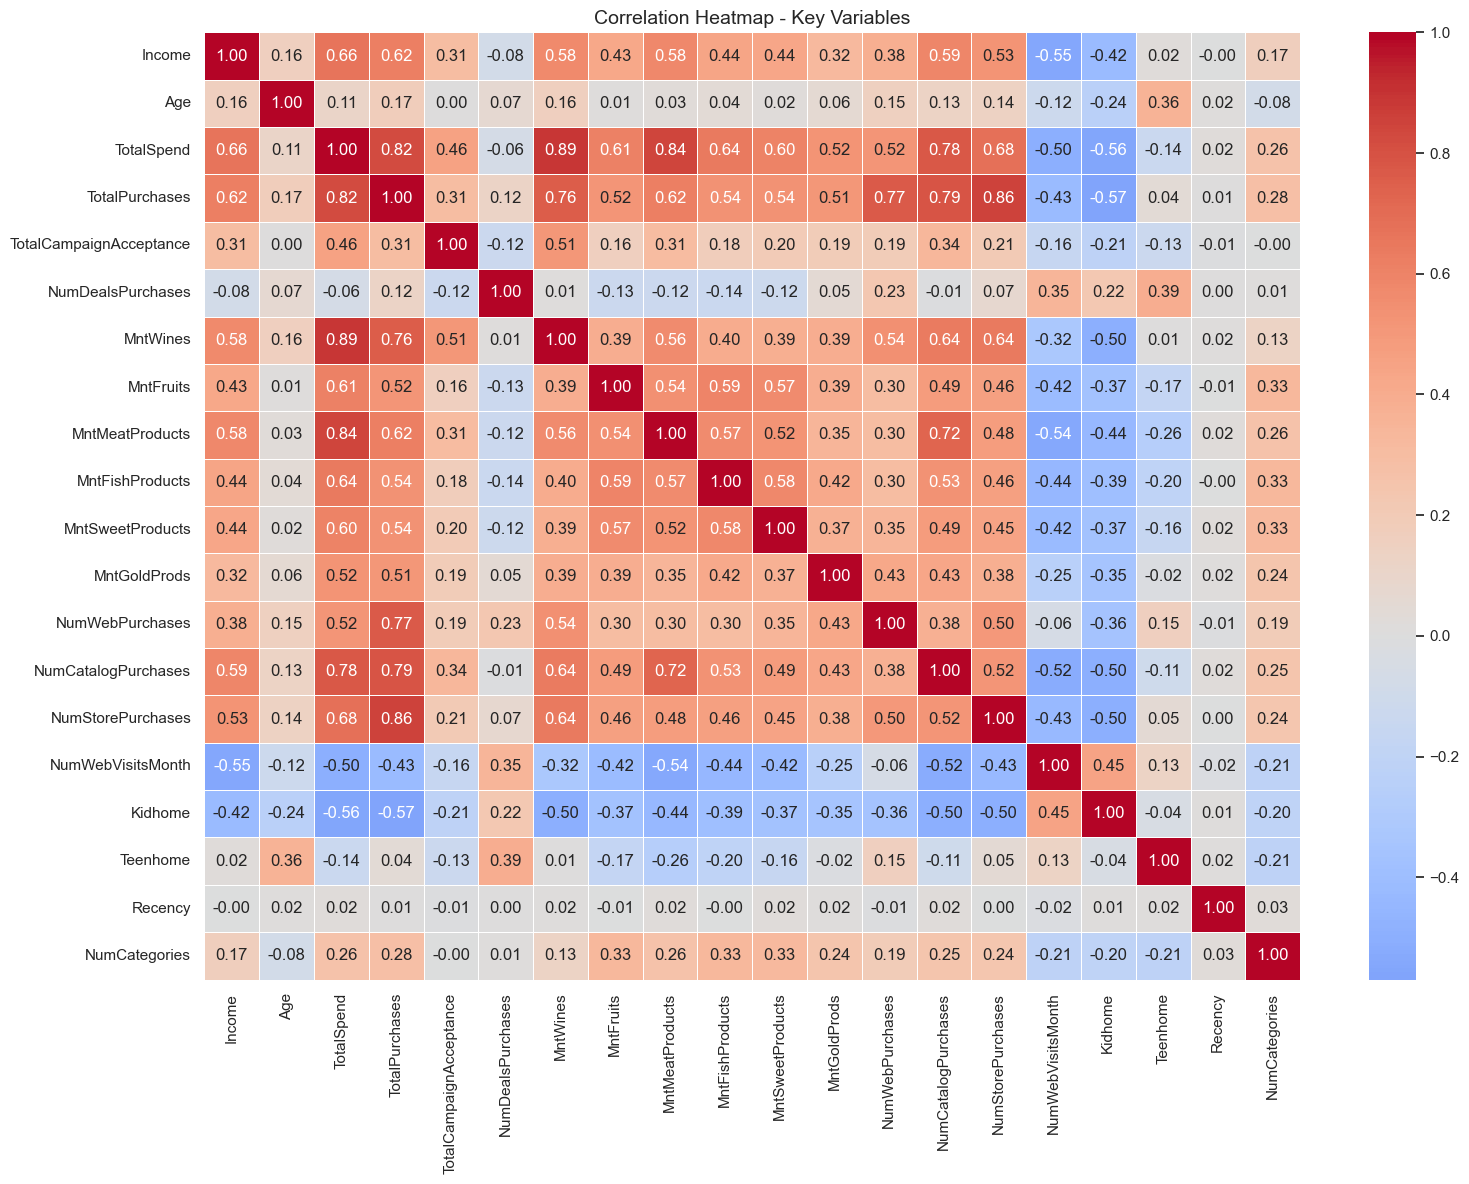

In [21]:
# A correlation heatmap shows how strongly pairs of variables are related.
# Values close to 1 mean they move together (positive correlation).
# Values close to -1 mean they move in opposite directions.
# Values close to 0 mean no relationship.

# Selecting the key columns for correlation analysis.
corr_cols = ['Income', 'Age', 'TotalSpend', 'TotalPurchases',
             'TotalCampaignAcceptance', 'NumDealsPurchases',
             'MntWines', 'MntFruits', 'MntMeatProducts',
             'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
             'NumWebPurchases', 'NumCatalogPurchases',
             'NumStorePurchases', 'NumWebVisitsMonth',
             'Kidhome', 'Teenhome', 'Recency', 'NumCategories']

# Calculating the correlation matrix.
corr_matrix = data[corr_cols].corr()

# Plotting the heatmap.
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=True,          # show the correlation number in each cell
            fmt='.2f',           # round to 2 decimal places
            cmap='coolwarm',     # red = positive, blue = negative
            center=0,            # white at zero correlation
            linewidths=0.5)

plt.title('Correlation Heatmap - Key Variables', fontsize=14)
plt.tight_layout()
plt.show()

#### 5.3 Question-Driven Bivariate Analysis

**(Question 1) Age vs Product Spending**

- **Wine** — older customers tend to spend more on wine. The ceiling
  of spending increases with age. Consistent with the weak positive
  correlation (0.16) seen in the heatmap
- **Meat** — highest spenders are concentrated in the 42-52 age range.
  Spending declines after that. Middle aged customers are the biggest
  meat spenders
- **Gold** — no clear age pattern. High gold spenders exist across all
  age groups but are few in number. Age does not predict gold spending <br>
**Answer to Question 1:** Age has a mild influence on wine and meat
spending but not on gold. It is not a strong driver of product category
preference overall.

**(Question 2) Income vs Promotion Usage**

- Deal usage is concentrated among low to moderate income customers
  (below 100,000). High income customers barely use deals at all
- Low income customers rely on deals to stretch their budget. High
  income customers do not need discounts to make purchase decisions
- Across all income levels the most common deal usage is 1-2 purchases.
  Very few customers use more than 5 deals regardless of income
- The type of products on deal is unknown from this dataset — it is
  possible deals are on everyday items rather than premium products
  which would explain why high income customers ignore them <br>
**Answer to Question 2:** Income negatively influences promotion usage.
Lower income customers are the primary deal users.

**(Question 3) Income vs Spend and Category Breadth**

- **Income vs TotalSpend** — positive relationship. As income increases
  spend increases. However, the relationship has wide variation — some
  low income customers spend high and some moderate income customers
  spend low. Income is a driver but not the only one
- **Income vs NumCategories** — income does not influence how many
  product categories customers buy from. The majority of customers
  across all income levels buy from all 6 categories
- This confirms our earlier finding that NumCategories has very little
  variation and will likely not be useful as a clustering feature <br>
**Answer to Question 3:** Income drives total spend but not category
breadth. Almost all customers buy across all product categories
regardless of income level.

**(Question 4) Age vs Purchase Channel**

- **Web purchases** — density is relatively flat across ages 35-75
  forming a plateau then drops at the older end. No strong age
  preference for web purchasing
- **Catalog purchases** — closest to a bell curve of all three channels.
  Concentration is highest in the 40-60 age range with lower usage
  at younger and older ends
- **Store purchases** — most uniform spread across all ages. Customers
  aged 45-65 tend to have higher store purchase quantities but all age
  groups shop in store <br>
**Answer to Question 4:** Age has a mild influence on channel preference.
Middle aged customers (40-65) are the most active across all three
channels simply because they represent the largest customer group.
No channel is exclusively dominated by one age group.

**(Question 5) Recency vs Total Spend**

- The scatter plot shows a completely random cloud with no visible
  direction or pattern
- High spenders and low spenders exist at every recency value from
  0 to 100 days
- Recency does not predict total spend — a customer who last bought
  yesterday is no more or less likely to be a high spender than one
  who last bought 90 days ago
- This confirms the near-zero correlation (0.02) seen in the heatmap <br>
**Answer to Question 5:** Recency has no relationship with overall
spending. How long since a customer last purchased tells us nothing
about how much they spend. <br>
**Limitation:** This dataset only contains total spend over 2 years,
not purchase history over time. We cannot track what customers buy
after a long gap — only their overall spending pattern.

**(Question 6) Education vs Spending**
- Wine spending increases consistently with education level from
  Basic to PhD. PhD customers spend the most on wine (~400 average)
- Meat products follow the same pattern — higher education, higher
  meat spend
- Basic education customers spend very little across all categories
- Gold products are more prominent in 2n Cycle and Graduation
  compared to Master and PhD
- The jump from Basic to 2n Cycle is significant despite both being
  undergraduate level — this is likely explained by income differences
  rather than education itself
- Education level appears to be a proxy for income — higher education
  correlates with higher income which drives higher spending. The
  relationship is income → spend, not education → spend directly

**(Question 7) Web Visits vs Web Purchases**

- Web visits and web purchases have a weak positive relationship —
  more visits loosely correlates with more purchases
- However visiting does not guarantee buying. Customers exist at
  every visit count who make zero purchases
- Adding income as a color dimension reveals the full story:
  - Low income customers (blue) are concentrated at high visit counts
    with low or zero purchases — they are browsers not buyers
  - Higher income customers (red/warm) visit less frequently but
    convert to purchases more reliably
- Web visit frequency is a signal of browsing behavior driven by
  low income, not buying intent <br>
**Answer to Question 7:** Web visits do not reliably predict web
purchases. High visit frequency signals low income browsing behavior.
Higher income customers visit less but buy more when they do.

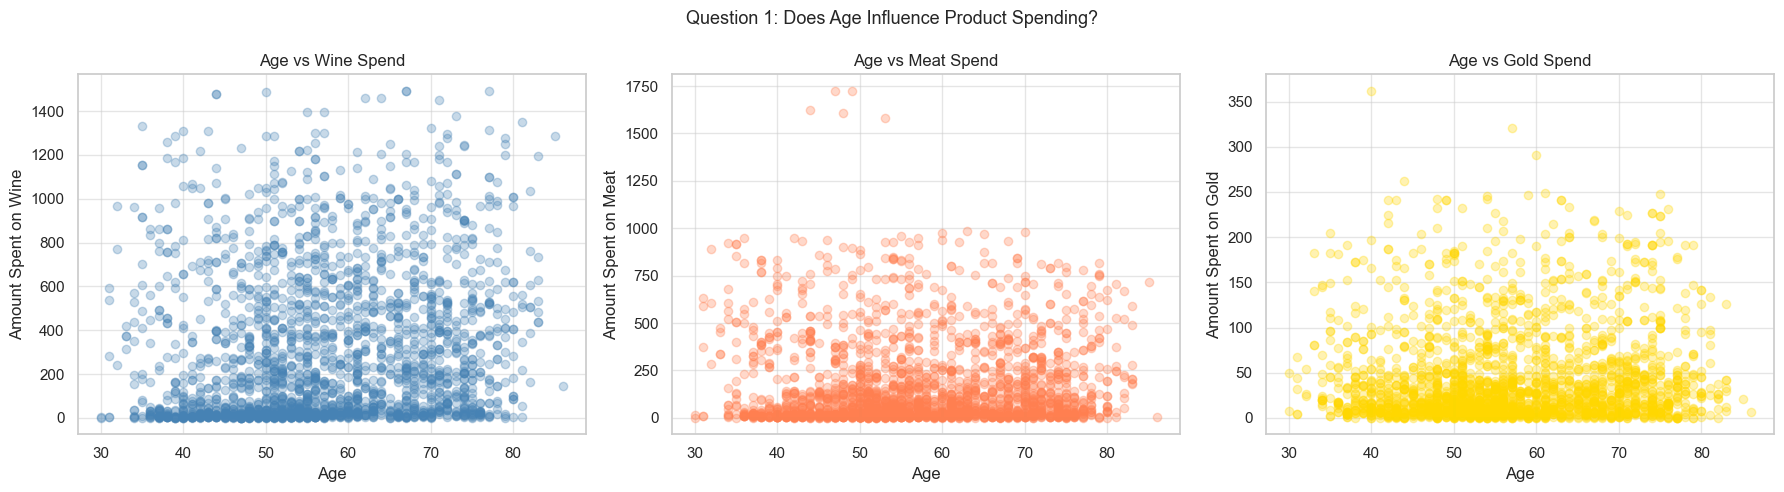

In [22]:
# Question 1: Does age influence which product categories customers buy?
# Using scatter plots to see if older or younger customers lean toward specific product categories.
# We use TotalSpend and the two biggest categories - Wine and Meat.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Wine
axes[0].scatter(data['Age'], data['MntWines'],
                alpha=0.3, color='steelblue')
axes[0].set_title('Age vs Wine Spend')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Amount Spent on Wine')

# Age vs Meat
axes[1].scatter(data['Age'], data['MntMeatProducts'],
                alpha=0.3, color='coral')
axes[1].set_title('Age vs Meat Spend')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Amount Spent on Meat')

# Age vs Gold
axes[2].scatter(data['Age'], data['MntGoldProds'],
                alpha=0.3, color='gold')
axes[2].set_title('Age vs Gold Spend')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Amount Spent on Gold')

plt.suptitle('Question 1: Does Age Influence Product Spending?',
             fontsize=13)
plt.tight_layout()
plt.show()

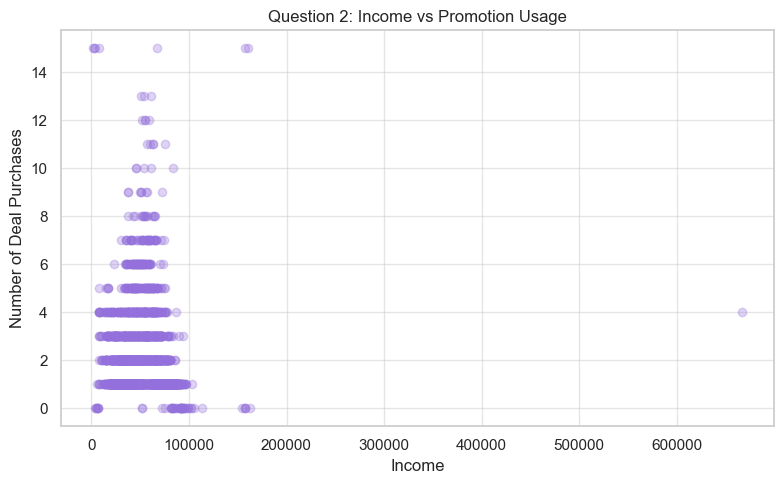

In [23]:
# Question 2: Does income influence promotion usage?
# NumDealsPurchases represents how many times a customer bought using a discount or deal.
# Scatter plot shows whether higher income customers use more or fewer deals.

plt.figure(figsize=(8, 5))
plt.scatter(data['Income'], data['NumDealsPurchases'],
            alpha=0.3, color='mediumpurple')
plt.title('Question 2: Income vs Promotion Usage')
plt.xlabel('Income')
plt.ylabel('Number of Deal Purchases')
plt.tight_layout()
plt.show()

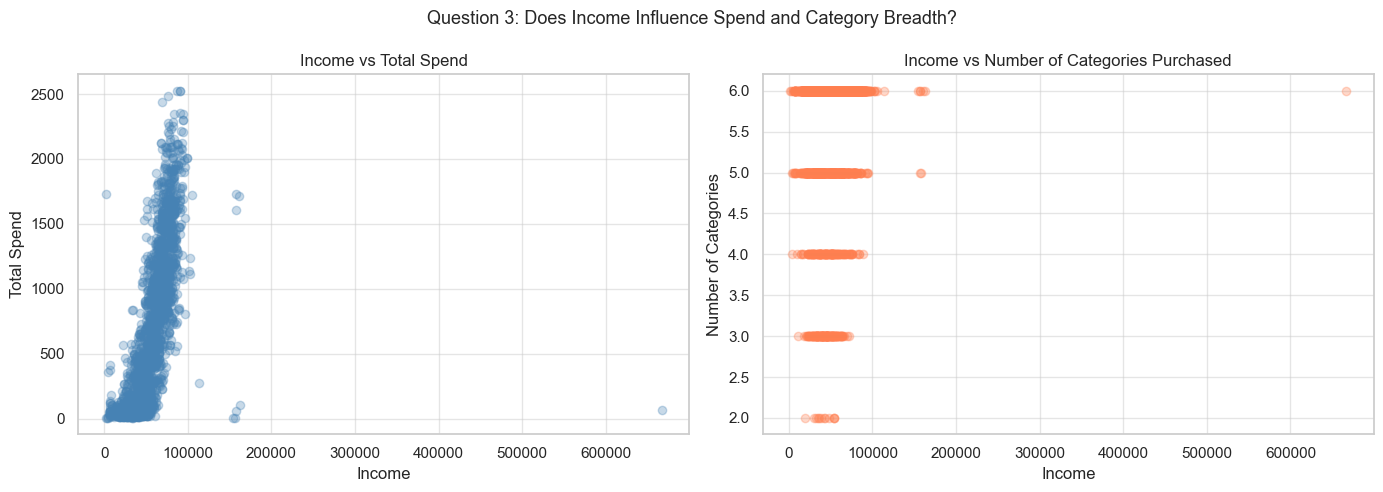

In [24]:
# Question 3: Does income influence total spend and category breadth?
# Two scatter plots side by side.
# Left: Income vs TotalSpend - does earning more mean spending more?
# Right: Income vs NumCategories - does earning more mean buying across more product categories?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income vs TotalSpend
axes[0].scatter(data['Income'], data['TotalSpend'],
                alpha=0.3, color='steelblue')
axes[0].set_title('Income vs Total Spend')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spend')

# Income vs NumCategories
axes[1].scatter(data['Income'], data['NumCategories'],
                alpha=0.3, color='coral')
axes[1].set_title('Income vs Number of Categories Purchased')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Number of Categories')

plt.suptitle('Question 3: Does Income Influence Spend and Category Breadth?',
             fontsize=13)
plt.tight_layout()
plt.show()

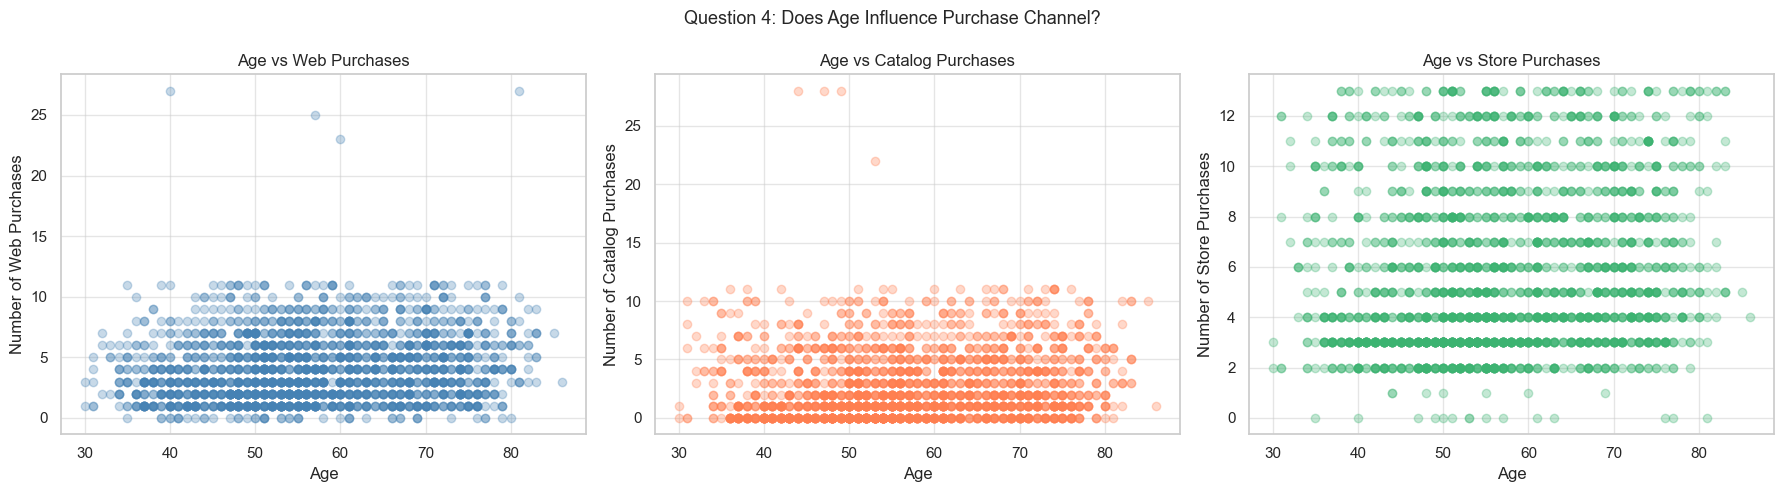

In [25]:
# Question 4: Does age influence which purchase channel customers use?
# Comparing age against each of the three purchase channels. Looking for whether older or younger customers prefer specific channels.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Web Purchases
axes[0].scatter(data['Age'], data['NumWebPurchases'],
                alpha=0.3, color='steelblue')
axes[0].set_title('Age vs Web Purchases')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Web Purchases')

# Age vs Catalog Purchases
axes[1].scatter(data['Age'], data['NumCatalogPurchases'],
                alpha=0.3, color='coral')
axes[1].set_title('Age vs Catalog Purchases')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Catalog Purchases')

# Age vs Store Purchases
axes[2].scatter(data['Age'], data['NumStorePurchases'],
                alpha=0.3, color='mediumseagreen')
axes[2].set_title('Age vs Store Purchases')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Number of Store Purchases')

plt.suptitle('Question 4: Does Age Influence Purchase Channel?',
             fontsize=13)
plt.tight_layout()
plt.show()

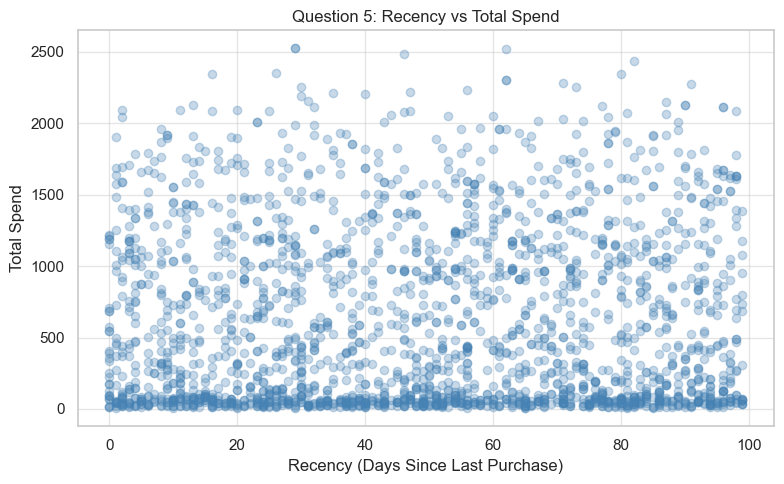

In [26]:
# Question 5: Does recency (gap since last purchase) relate to overall spend?
# Recency = number of days since last purchase.
# Higher recency means the customer has not bought in a long time. We want to know if dormant customers spend less overall.

plt.figure(figsize=(8, 5))
plt.scatter(data['Recency'], data['TotalSpend'],
            alpha=0.3, color='steelblue')
plt.title('Question 5: Recency vs Total Spend')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()

In [27]:
# Question 6: Does education level influence which product categories customers spend on?
# Education is categorical so we calculate the mean spend per category for each education level and plot as a bar chart.

# Checking what education values actually exist in the dataset before we define any ordering.
print(data['Education'].unique())
print()
print(data['Education'].value_counts())

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

Education
Graduation    1125
PhD            482
Master         368
2n Cycle       201
Basic           54
Name: count, dtype: int64


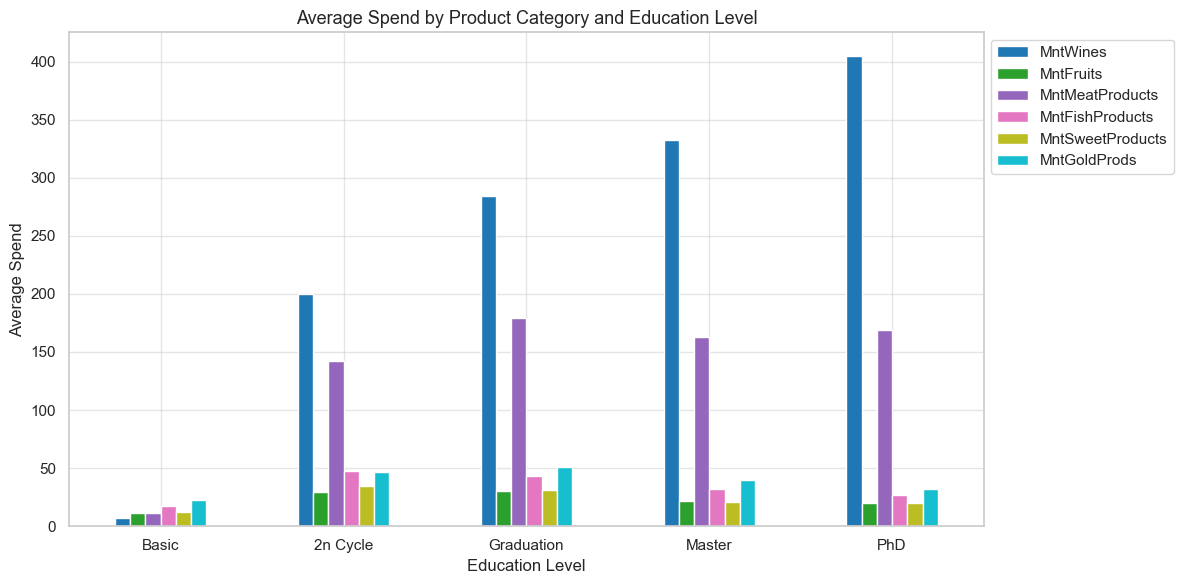

In [28]:
# Defining education order from lowest to highest based on dataset documentation.
edu_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

# Calculate mean spend per product category grouped by education level.
edu_spend = data.groupby('Education')[['MntWines', 'MntFruits',
                                        'MntMeatProducts', 'MntFishProducts',
                                        'MntSweetProducts',
                                        'MntGoldProds']].mean()

# Reorder rows to follow education hierarchy.
edu_spend = edu_spend.reindex(edu_order)

# Plot.
edu_spend.plot(kind='bar', figsize=(12, 6), colormap='tab10',
               edgecolor='white')

plt.title('Average Spend by Product Category and Education Level',
          fontsize=13)
plt.xlabel('Education Level')
plt.ylabel('Average Spend')
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

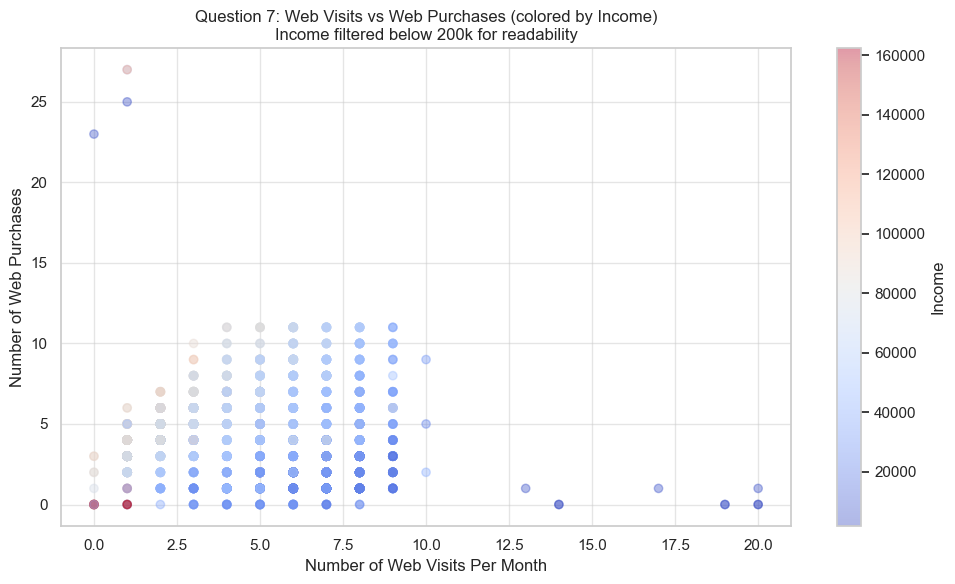

In [29]:
# Question 7: Does web visit frequency correlate with web purchases?
# Excluding the extreme income outlier (666k) so the color scale is meaningful across the majority of customers.

data_filtered = data[data['Income'] < 200000]

plt.figure(figsize=(10, 6))

scatter = plt.scatter(data_filtered['NumWebVisitsMonth'],
                      data_filtered['NumWebPurchases'],
                      c=data_filtered['Income'],
                      cmap='coolwarm',        # blue = low, red = high
                      alpha=0.4)

plt.colorbar(scatter, label='Income')
plt.title('Question 7: Web Visits vs Web Purchases (colored by Income)\n'
          'Income filtered below 200k for readability')
plt.xlabel('Number of Web Visits Per Month')
plt.ylabel('Number of Web Purchases')
plt.tight_layout()
plt.show()

### Step 6 — Hypothesis Formation

Variables with strong correlations (above 0.60) are included in
the model without testing — the signal is strong enough.
Hypotheses focus on variables with weak or ambiguous correlations
that need formal confirmation before including in clustering.

---

**Hypothesis 1 — Age and Wine Spending**
- H0: Age has no correlation to product category spending
- H1: Age has a weak positive correlation with wine spending.
  Older customers tend to spend more on wine

**Hypothesis 2 — Kids at Home and Deal Usage**
- H0: Having kids at home has no influence on deal usage
- H1: Customers with kids at home use significantly more deals
  than customers without kids

**Hypothesis 3 — Recency and Overall Spend**
- H0: There is no relationship between days since last purchase
  and overall spend
- H1: Customers with low recency (bought recently) spend more overall

**Hypothesis 4 — Web Visits and Web Purchases**
- H0: Web purchases are independent of web visit frequency
- H1: Customers who visit the company site more frequently
  tend to purchase more

**Hypothesis 5 — Campaign Acceptance and Overall Spend**
- H0: Campaign acceptance has no relationship with overall spend.
- H1: Customers who accept campaigns tend to have higher
    overall spend than those who do not.

**Hypothesis 6 — Education Level and Overall Spend**
- H0: Education level has no influence on total spend
- H1: Higher education customers spend significantly more overall

---

**Significance level for all tests: α = 0.05**

### Step 7 — Statistical Testing

Running a formal statistical test for each hypothesis formed in Step 6.
Significance level: α = 0.05

For each test:
- p < 0.05 → Reject H₀ → Pattern is statistically significant
- p > 0.05 → Fail to reject H₀ → Not enough evidence

---

**Statistical Testing Results**

| Hypothesis | Test | Result                               | Plain English Conclusion |
|---|---|--------------------------------------|---|
| H1: Age vs Wine Spend | Correlation | Reject H0 (p=0.000, r=0.163)         | Statistically significant but very weak (r=0.163). Age has a real but tiny influence on wine spending. Not practically useful for clustering — excluded |
| H2: Kids vs Deal Usage | ANOVA | Reject H0 (p=0.000, F=62.57)         | Strong and statistically significant. Customers with kids use significantly more deals. Large variation between groups — included in clustering consideration |
| H3: Recency vs Total Spend | Correlation | Fail to reject H0 (p=0.316, r=0.021) | Not statistically significant and extremely weak. Recency has no relationship with total spend — excluded |
| H4: Web Visits vs Web Purchases | Correlation | Reject H0 (p=0.008, r=-0.056)        | Statistically significant but negative and very weak. More web visits weakly associates with fewer purchases — confirms browsing behavior. Not useful for clustering — excluded |
| H5: Campaign Acceptance vs Total Spend | t-test | Reject H0 (p=0.000, t=21.57)         | Very strong and statistically significant. Campaign acceptors spend significantly more than non-acceptors — included in clustering consideration |
| H6: Education vs Total Spend | ANOVA | Reject H0 (p=0.000, F=13.60)         | Statistically significant. Education level influences spend but effect is moderate. Flagged for review in preprocessing step |

**Key decisions from hypothesis testing:**
- Age → excluded from clustering (too weak)
- Kids at home → included (strong signal)
- Recency → excluded (no relationship)
- Web visits → excluded (too weak, wrong direction)
- Campaign acceptance → included (strong signal)
- Education → flagged for review in preprocessing

In [30]:
# Importing the statistical testing library.
from scipy import stats

# Setting significance level.
alpha = 0.05

print("Statistical Testing Results")
print("=" * 50)

# ----------------------------------------
# H1: Age vs Wine Spending
# Two numeric variables - Correlation test
# ----------------------------------------
corr_h1, p_h1 = stats.pearsonr(data['Age'], data['MntWines'])
print(f"\nH1 — Age vs Wine Spending (Correlation Test)")
print(f"Correlation: {corr_h1:.4f} | p-value: {p_h1:.4f}")
if p_h1 < alpha:
    print("Result: Reject H₀ — Statistically significant")
else:
    print("Result: Fail to reject H₀ — Not significant")

# ----------------------------------------
# H2: Kids at Home vs Deal Usage
# 3 groups (0, 1, 2 kids) vs numeric - ANOVA
# ----------------------------------------
group_h2_0 = data[data['Kidhome'] == 0]['NumDealsPurchases']
group_h2_1 = data[data['Kidhome'] == 1]['NumDealsPurchases']
group_h2_2 = data[data['Kidhome'] == 2]['NumDealsPurchases']
f_h2, p_h2 = stats.f_oneway(group_h2_0, group_h2_1, group_h2_2)
print(f"\nH2 — Kids at Home vs Deal Usage (ANOVA)")
print(f"F-statistic: {f_h2:.4f} | p-value: {p_h2:.4f}")
if p_h2 < alpha:
    print("Result: Reject H₀ — Statistically significant")
else:
    print("Result: Fail to reject H₀ — Not significant")

# ----------------------------------------
# H3: Recency vs Total Spend
# Two numeric variables - Correlation test
# ----------------------------------------
corr_h3, p_h3 = stats.pearsonr(data['Recency'], data['TotalSpend'])
print(f"\nH3 — Recency vs Total Spend (Correlation Test)")
print(f"Correlation: {corr_h3:.4f} | p-value: {p_h3:.4f}")
if p_h3 < alpha:
    print("Result: Reject H₀ — Statistically significant")
else:
    print("Result: Fail to reject H₀ — Not significant")

# ----------------------------------------
# H4: Web Visits vs Web Purchases
# Two numeric variables - Correlation test
# ----------------------------------------
corr_h4, p_h4 = stats.pearsonr(data['NumWebVisitsMonth'],
                                data['NumWebPurchases'])
print(f"\nH4 — Web Visits vs Web Purchases (Correlation Test)")
print(f"Correlation: {corr_h4:.4f} | p-value: {p_h4:.4f}")
if p_h4 < alpha:
    print("Result: Reject H₀ — Statistically significant")
else:
    print("Result: Fail to reject H₀ — Not significant")

# ----------------------------------------
# H5: Campaign Acceptance vs Total Spend
# 2 groups vs numeric - t-test
# ----------------------------------------
no_campaign = data[data['TotalCampaignAcceptance'] == 0]['TotalSpend']
yes_campaign = data[data['TotalCampaignAcceptance'] > 0]['TotalSpend']
t_h5, p_h5 = stats.ttest_ind(yes_campaign, no_campaign)
print(f"\nH5 — Campaign Acceptance vs Total Spend (t-test)")
print(f"t-statistic: {t_h5:.4f} | p-value: {p_h5:.4f}")
if p_h5 < alpha:
    print("Result: Reject H₀ — Statistically significant")
else:
    print("Result: Fail to reject H₀ — Not significant")

# ----------------------------------------
# H6: Education Level vs Total Spend
# 5 groups vs numeric - ANOVA
# ----------------------------------------
edu_groups = [data[data['Education'] == edu]['TotalSpend']
              for edu in ['Basic', '2n Cycle', 'Graduation',
                          'Master', 'PhD']]
f_h6, p_h6 = stats.f_oneway(*edu_groups)
print(f"\nH6 — Education Level vs Total Spend (ANOVA)")
print(f"F-statistic: {f_h6:.4f} | p-value: {p_h6:.4f}")
if p_h6 < alpha:
    print("Result: Reject H₀ — Statistically significant")
else:
    print("Result: Fail to reject H₀ — Not significant")

Statistical Testing Results

H1 — Age vs Wine Spending (Correlation Test)
Correlation: 0.1629 | p-value: 0.0000
Result: Reject H₀ — Statistically significant

H2 — Kids at Home vs Deal Usage (ANOVA)
F-statistic: 62.7037 | p-value: 0.0000
Result: Reject H₀ — Statistically significant

H3 — Recency vs Total Spend (Correlation Test)
Correlation: 0.0200 | p-value: 0.3444
Result: Fail to reject H₀ — Not significant

H4 — Web Visits vs Web Purchases (Correlation Test)
Correlation: -0.0590 | p-value: 0.0053
Result: Reject H₀ — Statistically significant

H5 — Campaign Acceptance vs Total Spend (t-test)
t-statistic: 21.6033 | p-value: 0.0000
Result: Reject H₀ — Statistically significant

H6 — Education Level vs Total Spend (ANOVA)
F-statistic: 13.6690 | p-value: 0.0000
Result: Reject H₀ — Statistically significant


### Step 8 — Preprocessing for Modeling

Before clustering we need to:
1. Drop columns with no analytical value or redundant information
2. Encode categorical variables so K-Means can work with them
3. Scale all numeric features so no variable dominates distance
   calculations due to its range

Every decision is justified by EDA and hypothesis testing results.

---
**Applied preprocessing**

**Columns dropped (12):**
- ID — identifier, no analytical value
- Year_Birth — replaced by Age
- Dt_Customer — replaced by Customer_Tenure
- AcceptedCmp1-5 — replaced by TotalCampaignAcceptance
- Recency — no relationship with spend (H3, p=0.316)
- NumCategories — very low variation, 80% customers at 6
- Complain — not statistically significant (p=0.1106)
- Response — redundant with TotalCampaignAcceptance

**Encoding applied:**
- Education → ordinal encoding (0-4) preserving hierarchy
- Marital_Status → one-hot encoding (4 columns, Divorced as baseline)
  drop_first=True applied to avoid multicollinearity

**Scaling applied:**
- StandardScaler applied to all 24 features
- Brings all variables to the same scale so no single feature
  dominates distance calculations in K-Means

**Final dataset for modeling: 2,230 rows × 24 features**

In [31]:
# Creating a copy of the cleaned data specifically for clustering.
# We work on this copy so the original data is preserved for reference and visualization.
data_model = data.copy()

# Dropping columns that have no analytical value, are redundant, or were excluded based on hypothesis testing results.
drop_cols = [
    'ID',                # identifier - no analytical value
    'Year_Birth',        # replaced by Age
    'Dt_Customer',       # replaced by Customer_Tenure
    'AcceptedCmp1',      # replaced by TotalCampaignAcceptance
    'AcceptedCmp2',      # replaced by TotalCampaignAcceptance
    'AcceptedCmp3',      # replaced by TotalCampaignAcceptance
    'AcceptedCmp4',      # replaced by TotalCampaignAcceptance
    'AcceptedCmp5',      # replaced by TotalCampaignAcceptance
    'Recency',           # no relationship with spend (H3 - p=0.316)
    'NumCategories',     # very low variation - 80% customers at 6
    'Complain',          # not statistically significant (p=0.1106)
    'Response'           # redundant with TotalCampaignAcceptance
]

data_model = data_model.drop(columns=drop_cols)

print("Columns remaining after dropping:")
print(data_model.columns.tolist())
print()
print("Total columns:", len(data_model.columns))

Columns remaining after dropping:
['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'TotalSpend', 'TotalPurchases', 'TotalCampaignAcceptance', 'Age', 'Customer_Tenure']

Total columns: 21


In [32]:
# Encoding categorical variables so K-Means can work with them.

# Education - Ordinal Encoding
# There is a clear hierarchy from Basic to PhD so we assign
# ascending numbers to preserve that order.
edu_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

# Creating the mapping manually so it is easy to read.
edu_mapping = {
    'Basic'      : 0,
    '2n Cycle'   : 1,
    'Graduation' : 2,
    'Master'     : 3,
    'PhD'        : 4
}

# Replacing the text values with numbers using the mapping above.
data_model['Education'] = data_model['Education'].map(edu_mapping)

print("Education encoding:")
print(edu_mapping)
print()

# Marital Status - One Hot Encoding
# No natural order exists between marital status categories so we create a separate binary column for each category.
data_model = pd.get_dummies(data_model,
                             columns=['Marital_Status'],
                             drop_first=True)  # drop one to avoid multicollinearity

print("Columns after encoding:")
print(data_model.columns.tolist())
print()
print("Total columns:", len(data_model.columns))

Education encoding:
{'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}

Columns after encoding:
['Education', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'TotalSpend', 'TotalPurchases', 'TotalCampaignAcceptance', 'Age', 'Customer_Tenure', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']

Total columns: 24


In [33]:
# Scaling all features using StandardScaler.
scaler = StandardScaler()

# Fitting the scaler and transforming the data.
data_scaled = scaler.fit_transform(data_model)

# Converting back to a DataFrame so column names are preserved.
data_scaled_df = pd.DataFrame(data_scaled, columns=data_model.columns)

print("Shape after scaling:", data_scaled_df.shape)
print()
print("Sample of scaled data:")
print(data_scaled_df.head())

Shape after scaling: (2230, 24)

Sample of scaled data:
   Education    Income   Kidhome  Teenhome  MntWines  MntFruits  \
0  -0.457341  0.235966 -0.825281 -0.929620  0.982341   1.554427   
1  -0.457341 -0.234617  1.031809  0.906565 -0.870089  -0.636292   
2  -0.457341  0.773621 -0.825281 -0.929620  0.361896   0.572380   
3  -0.457341 -1.020572  1.031809 -0.929620 -0.870089  -0.560750   
4   1.536541  0.242150  1.031809 -0.929620 -0.389170   0.421296   

   MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  ...  \
0         1.678375         2.470751          1.473303      0.850944  ...   
1        -0.713484        -0.650799         -0.631912     -0.729510  ...   
2        -0.177530         1.350665         -0.147954     -0.035652  ...   
3        -0.651473        -0.503903         -0.583516     -0.748784  ...   
4        -0.217395         0.157131         -0.002767     -0.556046  ...   

   NumWebVisitsMonth  TotalSpend  TotalPurchases  TotalCampaignAcceptance  \
0      

### Step 9 — Model Building

Finding the optimal number of clusters using two methods:
1. Elbow Plot — looks for the point where adding more clusters
   stops improving the model significantly
2. Silhouette Score — measures how well separated the clusters are

Both methods together give a more confident K selection than
either alone.

---

**Model Results** <br>

**K Selection:**
- Elbow plot shows inertia bending at K=3
- Silhouette score peaks locally at K=4 (0.1901) before a sharp
  drop at K=5 (0.1281)
- K=4 chosen as the optimal number of clusters — provides more
  granular and actionable business segments than K=2 or K=3

**Final Model Results:**
- K: 4 clusters
- Training time: 0.0498 seconds — fast training indicating the
  model will scale well as the dataset grows
- Inertia: 33,966.42
- Silhouette Score: 0.1901

In [34]:
# Running K-Means for K values from 2 to 10.
# by default - we look for the elbow where improvement slows down.

inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled_df)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(data_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f} | "
          f"Silhouette Score: {score:.4f}")

K=2 | Inertia: 39410.74 | Silhouette Score: 0.2609
K=3 | Inertia: 35770.39 | Silhouette Score: 0.1840
K=4 | Inertia: 33966.42 | Silhouette Score: 0.1901
K=5 | Inertia: 32798.74 | Silhouette Score: 0.1281
K=6 | Inertia: 31485.28 | Silhouette Score: 0.1042
K=7 | Inertia: 30280.76 | Silhouette Score: 0.1166
K=8 | Inertia: 28848.02 | Silhouette Score: 0.1390
K=9 | Inertia: 28135.18 | Silhouette Score: 0.1214
K=10 | Inertia: 27415.17 | Silhouette Score: 0.1212


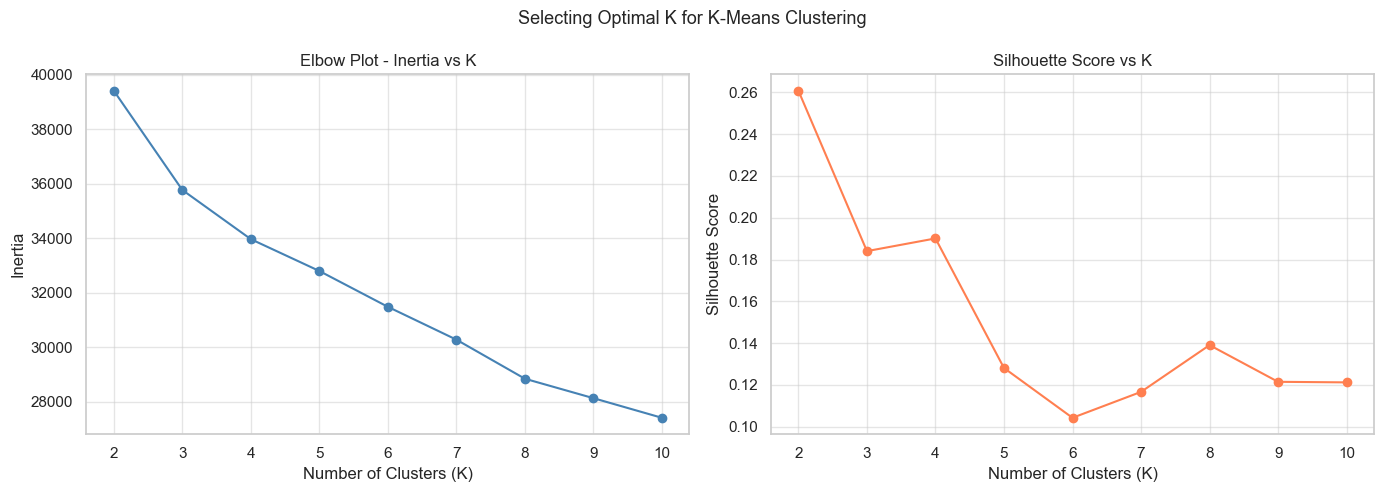

In [35]:
# Plotting the Elbow Plot and Silhouette Scores side by side.
# This helps us visually identify the optimal K.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(K, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Plot - Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# Silhouette Score Plot
axes[1].plot(K, silhouette_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Selecting Optimal K for K-Means Clustering', fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
# Fitting the final K-Means model with K=4.
# K=4 chosen based on:
# - Elbow plot shows bend starting at K=3
# - Silhouette score peaks locally at K=4 (0.190) before a sharp drop at K=5 (0.128)
# - 4 clusters provides more actionable business segments than 2 or 3

k = 4

# Recording start time to measure how long the model takes to train.
start_time = time.time()

# Initializing and fitting the K-Means model.
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_final.fit(data_scaled_df)

# Recording end time.
end_time = time.time()

print(f"Model training time: {end_time - start_time:.4f} seconds")
print(f"Final K: {k}")
print(f"Final Inertia: {kmeans_final.inertia_:.2f}")
print(f"Final Silhouette Score: {silhouette_score(data_scaled_df, kmeans_final.labels_):.4f}")

# Adding cluster labels back to the original data for profiling.
data['Cluster'] = kmeans_final.labels_
data_model['Cluster'] = kmeans_final.labels_

Model training time: 0.0440 seconds
Final K: 4
Final Inertia: 33966.42
Final Silhouette Score: 0.1901


### Step 10 — Model Evaluation

Evaluating the quality of the clusters using two approaches:
1. Silhouette score per cluster — checks if each individual cluster
   is well formed, not just the overall average
2. PCA 2D visualization — reduces 24 dimensions to 2 so we can
   visually inspect whether clusters are separable

---
**Evaluation Results** <br>

**Silhouette Scores per Cluster:**
- Cluster 1 — highest score (0.297), largest group (1,012 customers).
  Most well defined and distinct cluster
- Cluster 3 — score (0.216), smallest group (77 customers).
  Small but relatively distinct — possible niche segment
- Cluster 0 — score (0.109), 581 customers. Moderate overlap with
  neighboring clusters
- Cluster 2 — lowest score (0.077), 560 customers. Most overlap
  with other clusters. Customers here share characteristics with
  neighboring groups — boundaries are blurry

**PCA Visualization:**
- Clusters 0, 1, and 2 are visually separable in 2D PCA space
- Cluster 3 (77 customers) sits in the overlap zone between
  Cluster 0 and Cluster 1 — not in its own distinct space
- PC1 explains 33.0% of variance, PC2 explains 9.1% — total 42.1%
- 58% of variance is lost in this 2D projection. Clusters may be
  more separated in the full 24-dimensional space than visible here

**Flagged for Step 12 — Model Tuning:**
- Cluster 2 has low silhouette score — test K=3 to see if removing
  this cluster improves overall separation
- Cluster 3 overlaps with Clusters 0 and 1 visually — investigate
  whether K=3 absorbs it meaningfully

In [37]:
# Silhouette score per cluster.

from sklearn.metrics import silhouette_samples

sample_scores = silhouette_samples(data_scaled_df, kmeans_final.labels_)

print("Silhouette Score per Cluster:")
print("-" * 35)
for cluster in range(k):
    cluster_scores = sample_scores[kmeans_final.labels_ == cluster]
    print(f"Cluster {cluster} | "
          f"Mean Score: {cluster_scores.mean():.4f} | "
          f"Size: {len(cluster_scores)} customers")

Silhouette Score per Cluster:
-----------------------------------
Cluster 0 | Mean Score: 0.1093 | Size: 581 customers
Cluster 1 | Mean Score: 0.2970 | Size: 1012 customers
Cluster 2 | Mean Score: 0.0773 | Size: 560 customers
Cluster 3 | Mean Score: 0.2159 | Size: 77 customers


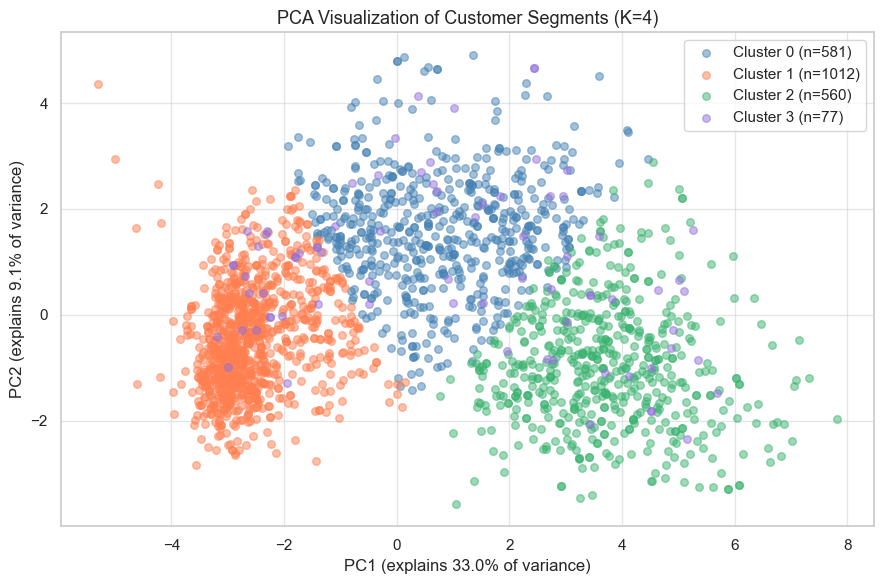


Total variance explained by 2 components: 42.1%


In [38]:
# Reducing 24 dimensions to 2 using PCA so we can visually inspect whether the 4 clusters are separable.

pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_scaled_df)

# Converting to DataFrame for plotting.
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans_final.labels_

# Plotting the clusters in 2D PCA space.
plt.figure(figsize=(9, 6))

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for cluster in range(k):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'],
                cluster_data['PC2'],
                c=colors[cluster],
                label=f'Cluster {cluster} (n={len(cluster_data)})',
                alpha=0.5,
                s=30)

plt.title('PCA Visualization of Customer Segments (K=4)', fontsize=13)
plt.xlabel(f'PC1 (explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 (explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 2 components: "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")

### Step 11 — Initial Insights
Profiling each cluster

---
Observations

**Cluster 0 — Deal Seekers (581 customers)**
- Moderate income (57,782) and moderate total spend (721)
- Highest deal usage of all clusters (3.76 deals)
- Active web purchasers (6.25) and highest web visits (5.75)
- Moderate wine and meat spend
- These customers spend reasonably but rely on deals to do so

**Cluster 1 — Budget Browsers (1,012 customers)**
- Lowest income (34,992) and lowest spend (97) of all clusters
- Lowest purchases across all channels
- Highest web visits (6.18) but very low web purchases (2.11)
- Highest Kidhome (0.80) — most likely to have kids at home
- Classic browsing behavior — visit frequently but rarely convert

**Cluster 2 — Premium Loyalists (560 customers)**
- Highest income (77,022) and highest spend (1,387)
- Highest campaign acceptance (0.72) — most responsive to marketing
- Lowest deal usage (1.33) — don't need discounts
- Highest wine (616) and meat (457) spend
- Fewest web visits (2.94) but high catalog and store purchases
- High value, campaign responsive, premium product buyers

**Cluster 3 — Campaign Responsive Seniors (77 customers)**
- Oldest customers (67.44 average age)
- Similar income to Cluster 0 but fewer purchases
- Higher campaign acceptance (0.36) than Clusters 0 and 1
- Less web activity — prefer traditional channels
- Small but distinct niche segment

**Key Takeaway:**
The four clusters tell a clear story — from Budget Browsers who
barely buy, to Deal Seekers who need incentives, to Campaign
Responsive Seniors who respond to outreach, to Premium Loyalists
who spend freely and respond strongly to campaigns.

In [39]:
# Calculating mean values of key variables per cluster.
# This gives us a profile of the typical customer in each cluster.

profile_cols = ['Income', 'Age', 'TotalSpend', 'TotalPurchases',
                'TotalCampaignAcceptance', 'NumDealsPurchases',
                'MntWines', 'MntMeatProducts', 'MntGoldProds',
                'NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumWebVisitsMonth',
                'Kidhome', 'Teenhome', 'Customer_Tenure']

cluster_profile = data.groupby('Cluster')[profile_cols].mean().round(2)

print("Cluster Profiles — Mean Values:")
print(cluster_profile.T)

Cluster Profiles — Mean Values:
Cluster                         0         1         2         3
Income                   57781.58  34992.30  77022.27  56415.32
Age                         61.32     54.08     56.81     67.44
TotalSpend                 721.07     97.08   1387.45    738.82
TotalPurchases              17.03      5.86     19.70     14.36
TotalCampaignAcceptance      0.25      0.08      0.72      0.36
NumDealsPurchases            3.76      2.05      1.33      2.34
MntWines                   451.59     41.48    616.69    369.27
MntMeatProducts            134.60     23.15    457.83    189.29
MntGoldProds                60.36     15.34     76.46     56.77
NumWebPurchases              6.25      2.11      5.34      4.62
NumCatalogPurchases          3.08      0.54      5.97      3.32
NumStorePurchases            7.71      3.21      8.39      6.42
NumWebVisitsMonth            5.69      6.46      2.92      4.88
Kidhome                      0.24      0.80      0.05      0.23
Teenhome

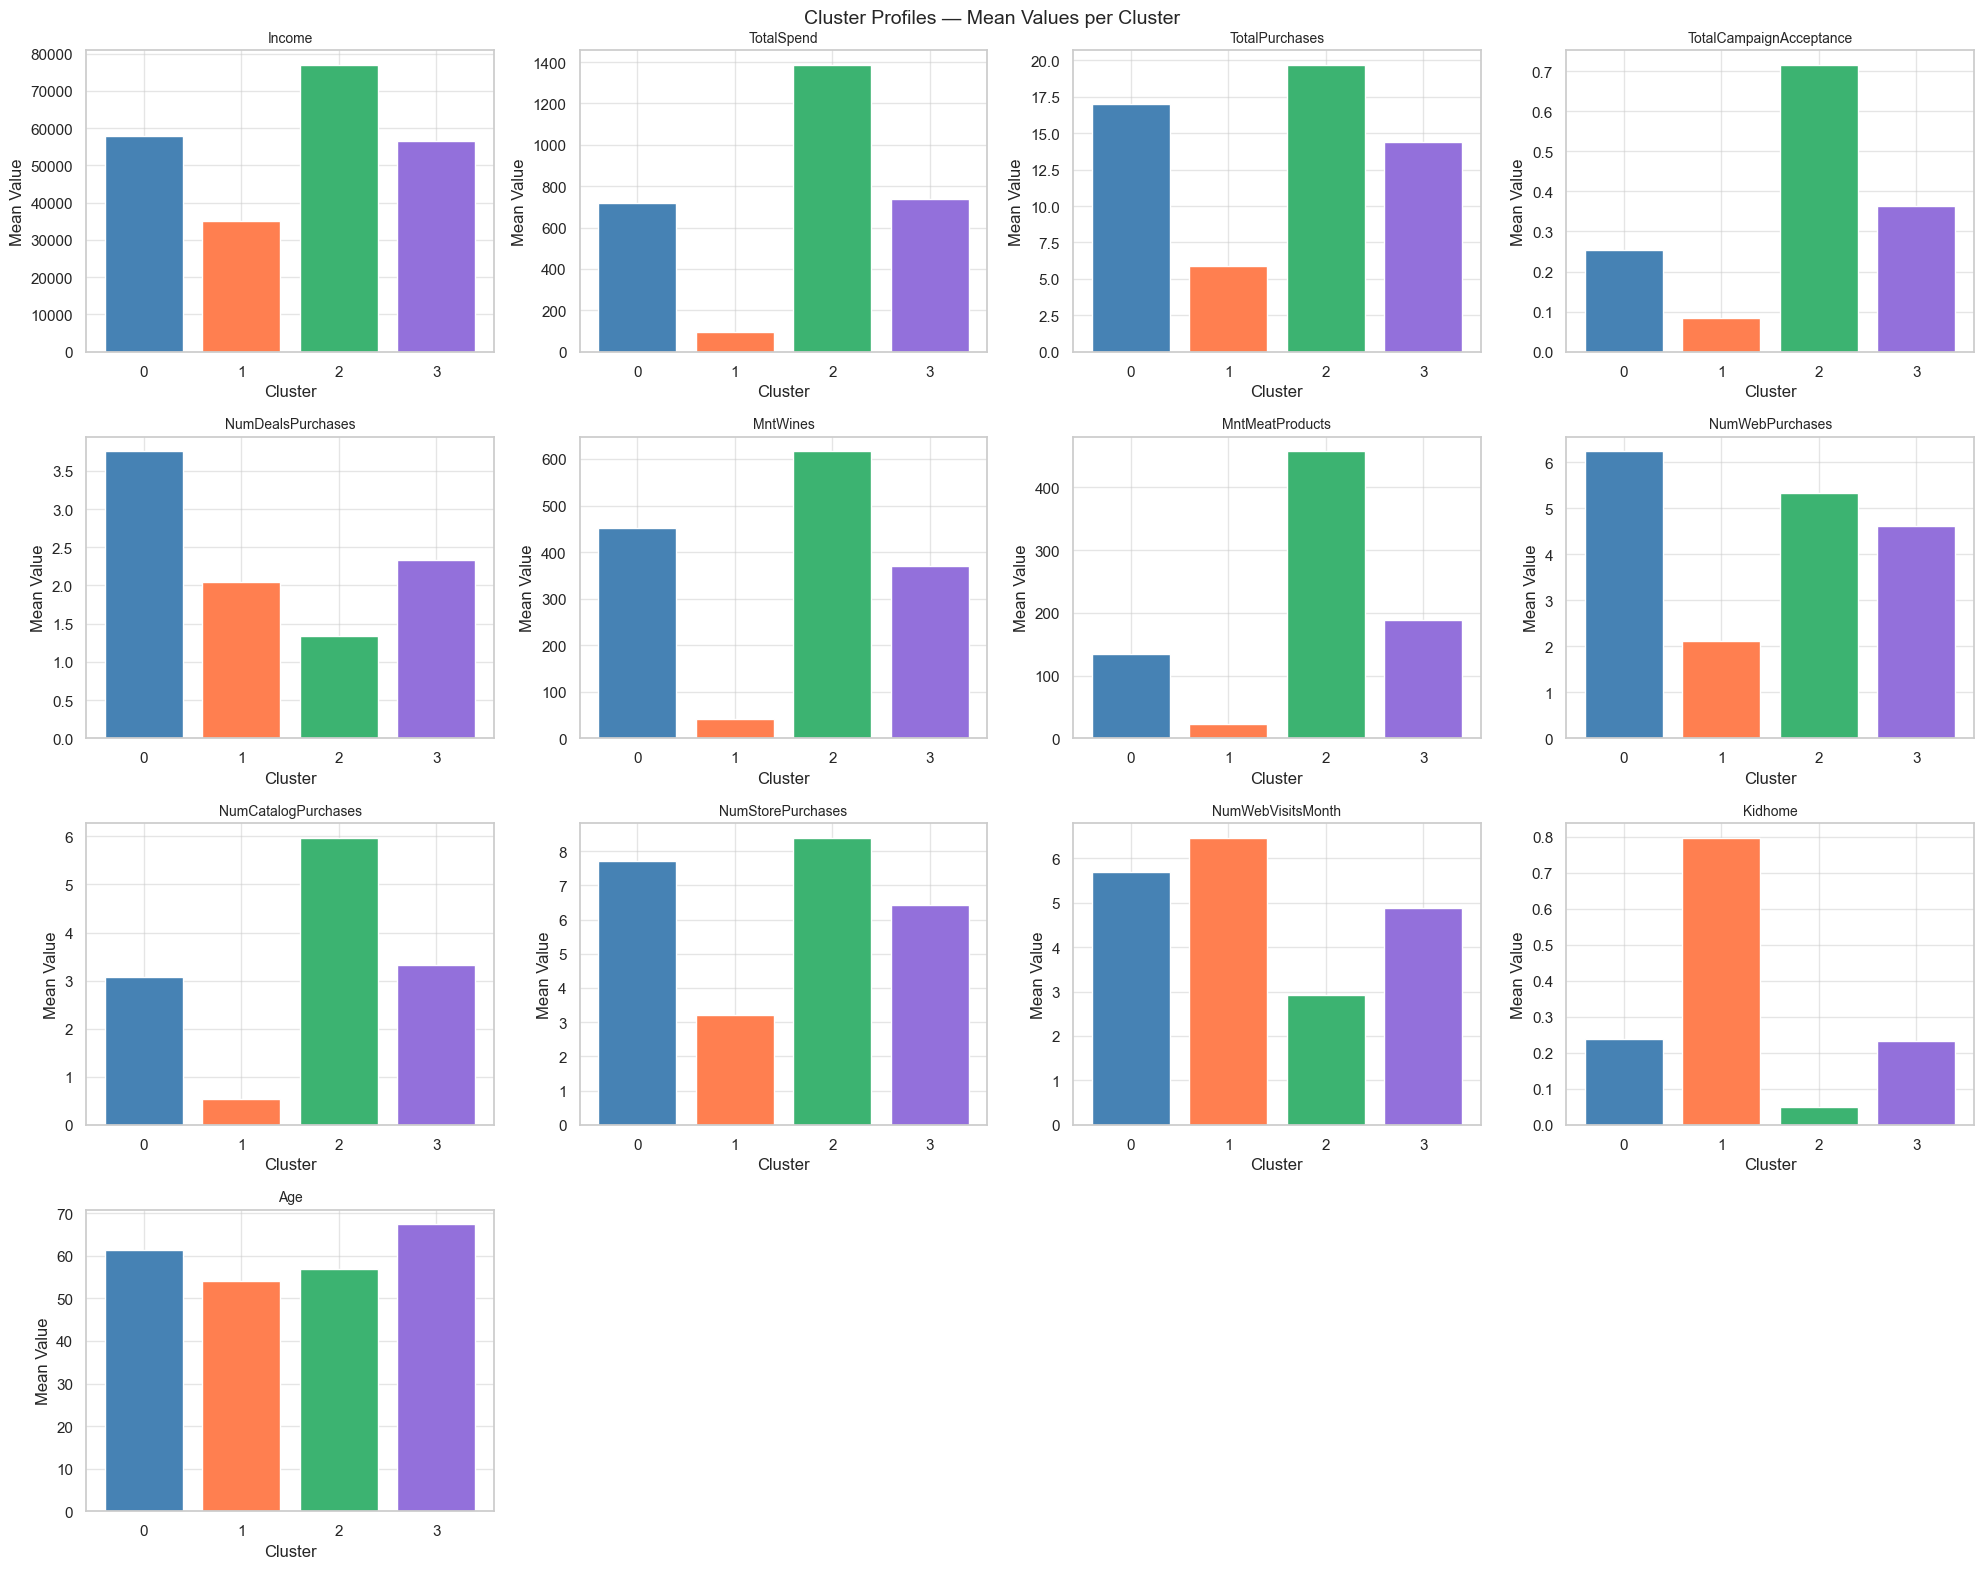

In [40]:
# Visualizing cluster profiles using bar plots.
# Comparing mean values of key variables across all 4 clusters.
# This confirms the characterizations we derived from the numbers.

key_profile_cols = ['Income', 'TotalSpend', 'TotalPurchases',
                    'TotalCampaignAcceptance', 'NumDealsPurchases',
                    'MntWines', 'MntMeatProducts',
                    'NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumWebVisitsMonth',
                    'Kidhome', 'Age']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for i, col in enumerate(key_profile_cols):
    cluster_means = data.groupby('Cluster')[col].mean()
    axes[i].bar(cluster_means.index, cluster_means.values,
                color=colors)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Mean Value')

# Hiding the last empty subplot.
axes[13].set_visible(False)
axes[14].set_visible(False)
axes[15].set_visible(False)

plt.suptitle('Cluster Profiles — Mean Values per Cluster',
             fontsize=14)
plt.tight_layout()
plt.show()

### Step 12 — Model Tuning + Updated Insights

Testing K=3 to see if reducing clusters improves separation.
Motivation from Step 10:
- Cluster 2 has the lowest silhouette score (0.077) — blurry boundaries
- Cluster 3 has only 77 customers and overlaps with Clusters 0 and 1
  in PCA space
- K=3 may produce cleaner, more separable clusters

---
**K=3 vs K=4 Comparison:**

| Metric | K=4 | K=3 |
|---|---|---|
| Silhouette Score | 0.1901 | 0.1840 |
| Inertia | 33,966 | 35,770 |
| Weakest cluster score | 0.077 | 0.075 |

**Findings:**
- K=4 has a higher silhouette score than K=3
- K=3 does not solve the weak cluster problem — Cluster 2 remains
  blurry at both K values
- K=3 absorbs the 77 Campaign Responsive Seniors into other clusters
  losing a distinct and actionable business segment
- Higher inertia at K=3 means clusters are less tight

**Decision: K=4 is the final model.**

**Updated Insights:**
- No changes to cluster profiles from Step 11
- K=4 cluster characterizations are confirmed as the final segmentation
- Cluster 2 (Budget Browsers) will always have some overlap — this
  reflects the reality that low value customers share characteristics
  across segments

In [41]:
# Testing K=3 and comparing against K=4.

k_tuned = 3

kmeans_k3 = KMeans(n_clusters=k_tuned, random_state=42, n_init=10)
kmeans_k3.fit(data_scaled_df)

sil_k3 = silhouette_score(data_scaled_df, kmeans_k3.labels_)
sil_k4 = silhouette_score(data_scaled_df, kmeans_final.labels_)

print("Model Comparison:")
print("-" * 40)
print(f"K=4 | Silhouette Score: {sil_k4:.4f} | Inertia: {kmeans_final.inertia_:.2f}")
print(f"K=3 | Silhouette Score: {sil_k3:.4f} | Inertia: {kmeans_k3.inertia_:.2f}")
print()

# Silhouette score per cluster for K=3.
sample_scores_k3 = silhouette_samples(data_scaled_df, kmeans_k3.labels_)

print("Silhouette Score per Cluster (K=3):")
print("-" * 40)
for cluster in range(k_tuned):
    cluster_scores = sample_scores_k3[kmeans_k3.labels_ == cluster]
    print(f"Cluster {cluster} | "
          f"Mean Score: {cluster_scores.mean():.4f} | "
          f"Size: {len(cluster_scores)} customers")

Model Comparison:
----------------------------------------
K=4 | Silhouette Score: 0.1901 | Inertia: 33966.42
K=3 | Silhouette Score: 0.1840 | Inertia: 35770.39

Silhouette Score per Cluster (K=3):
----------------------------------------
Cluster 0 | Mean Score: 0.2932 | Size: 1041 customers
Cluster 1 | Mean Score: 0.1015 | Size: 602 customers
Cluster 2 | Mean Score: 0.0750 | Size: 587 customers


### Step 13 — Business Recommendations

Based on the four customer segments identified, here are targeted
recommendations for each cluster.

---
**Cluster 0 — Deal Seekers (581 customers)**

Moderate income customers who are active web visitors that convert
to purchases. Second highest web purchases of all clusters. They
respond well to deals but not to standard campaigns. Deal-dependent
buyers who can be gradually moved toward higher value purchasing
with the right incentives.

Recommendations:
1. **Targeted email campaigns:** Reach via email with curated product
   pairings — wine and meat combinations that feel premium but are
   delivered as value offers
2. **Same day store pickup:** Offer same day in-store pickup incentives
   to leverage their dual web and store presence. Convenience drives
   conversion for this group
3. **Structured premium offers:** Run buy 1 get 20% off style campaigns
   on new or early release products. This bridges their deal-seeking
   behavior with a premium feel — gradually moving them up the
   value ladder

**Cluster 1 — Budget Browsers (1,012 customers)**

Low income customers who are frequent web visitors but rarely convert
to purchases. They browse like window shoppers — high web visits but
low buying activity. Highest Kidhome of all clusters indicating many
have children at home.

Recommendations:
1. **Channel — Web and Email:** Reach this group through their
   preferred channel — the company website and email. Use customer
   portal inbox deals and targeted landing pages
2. **Kid-friendly deals:** Promote sweets and fruits deals targeting
   the family household dynamic
3. **Personal deals:** Occasional wine and meat deals to nudge
   personal spending where intent already exists
4. **Low investment, periodic outreach:** Keep marketing costs minimal
   for this group. Run quarterly outreach and measure conversion
   before increasing investment

**Cluster 2 — Premium Loyalists (560 customers)**

Highest income customers who spend generously across all product
categories. They rarely rely on deals — they buy because they want to.
Highest campaign acceptance (0.72) of all clusters indicating strong
responsiveness to targeted marketing. Lowest web visits but second
highest web purchases — they visit with intent, not to browse.
Frequent store visitors suggesting preference for in-store experience.

Recommendations:
1. **Premium campaigns:** Target with exclusive campaigns featuring
   top shelf wine and meat selections, new product launches, and
   early access offers. This group responds to exclusivity not discounts
2. **Physical mail and catalog:** Reach through catalog and physical
   mail — consistent with their low web visit but high purchase
   conversion behavior
3. **In-store experience:** Maintain premium product selection in
   stores. Identify store locations with high Cluster 2 concentration
   and ensure wine and meat sections reflect premium quality
4. **Moderate investment:** They are already high spenders with strong
   campaign response. Maintain current investment level — focus on
   quality of outreach not volume

**Cluster 3 — Campaign Responsive Seniors (77 customers)**

Oldest customer segment (average age 67) with moderate income.
Strong preference for in-store purchases followed by web. Web visits
and web purchases are closely matched indicating they purchase with
intent when they visit online — not browsers. Second highest Teenhome
suggesting many have teenagers at home. Moderate campaign responsiveness
with potential to move up the value ladder.

Recommendations:
1. **Premium campaign outreach:** This group responds moderately to
   campaigns. Introduce premium brand messaging — wine selections
   and new product launches to gradually increase their spend
2. **In-store wine tasting events:** Leverage their strong store
   preference by organizing in-store tastings of premium wine and
   meat products. experiential marketing is likely to increase spend
   and move them toward Cluster 2 behavior over time
3. **Teen-angle deals:** Moderate deal purchasers with teens at home.
   Target with fruits and sweets deals to address the family household
   dynamic and increase basket size
